# COMP30027 Machine Learning 

## Assignment 2

In [77]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
from scipy.spatial.distance import cdist
from tqdm import tqdm
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from sklearn.feature_selection import mutual_info_classif
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import mutual_info_regression
from sklearn.ensemble import RandomForestClassifier

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from scipy.stats import norm
import pandas as pd
from sklearn.preprocessing import OneHotEncoder
from sklearn.feature_selection import mutual_info_classif
from sklearn.model_selection import cross_val_predict



## Intrduction of dataset

In [78]:
df = pd.read_csv('project_data/train_dataset.csv')
#test_data = pd.read_csv('test_dataset.csv')

In [79]:
df['language']

0       English
1       English
2       English
3       English
4       English
         ...   
2999    English
3000    English
3001    English
3002     Arabic
3003    Spanish
Name: language, Length: 3004, dtype: object

In [81]:
df.info()
df.describe() 
df.head()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3004 entries, 0 to 3003
Data columns (total 27 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   id                         3004 non-null   int64  
 1   director_name              3004 non-null   object 
 2   num_critic_for_reviews     3004 non-null   int64  
 3   duration                   3004 non-null   int64  
 4   director_facebook_likes    3004 non-null   int64  
 5   actor_3_facebook_likes     3004 non-null   int64  
 6   actor_2_name               3004 non-null   object 
 7   actor_1_facebook_likes     3004 non-null   int64  
 8   gross                      3004 non-null   int64  
 9   genres                     3004 non-null   object 
 10  actor_1_name               3004 non-null   object 
 11  movie_title                3004 non-null   object 
 12  num_voted_users            3004 non-null   int64  
 13  cast_total_facebook_likes  3004 non-null   int64

,id,director_name,num_critic_for_reviews,duration,director_facebook_likes,actor_3_facebook_likes,actor_2_name,actor_1_facebook_likes,gross,genres,...,num_user_for_reviews,language,country,content_rating,title_year,actor_2_facebook_likes,movie_facebook_likes,title_embedding,average_degree_centrality,imdb_score_binned
0,1,Roger Allers,186,73,28,847,Nathan Lane,2000,422783777,Adventure|Animation|Drama|Family|Musical,...,656,English,USA,G,1994,886,17000,[-4.1984697e-03 4.2941985e-03 -1.1961063e-03 ...,0.001576,4
1,2,George A. Romero,252,97,0,233,Shawn Roberts,654,20433940,Horror,...,662,English,Canada,R,2005,529,0,[-4.7586653e-03 2.6511205e-03 -3.7954253e-04 ...,0.000675,2
2,3,David Gordon Green,232,117,234,221,Tye Sheridan,12000,371897,Drama,...,118,English,USA,R,2013,1000,11000,[ 2.78131524e-03 -3.15494463e-03 -6.38332494e-...,0.003002,2
3,4,John Carpenter,297,109,0,145,Richard Masur,957,13782838,Horror|Mystery|Sci-Fi,...,911,English,USA,R,1982,163,23000,[-5.32674184e-03 3.60742491e-03 7.91795843e-...,0.001726,4
4,5,Peter Jackson,297,171,0,857,Orlando Bloom,16000,313837577,Action|Adventure|Drama|Fantasy,...,5060,English,New Zealand,PG-13,2001,5000,21000,[-4.2586620e-03 3.6257182e-03 -1.5326265e-03 ...,0.001876,4


In [82]:

df.select_dtypes(include=['object']).columns

Index(['director_name', 'actor_2_name', 'genres', 'actor_1_name',
       'movie_title', 'actor_3_name', 'plot_keywords', 'language', 'country',
       'content_rating', 'title_embedding'],
      dtype='object')

## Feature Selection

### Log

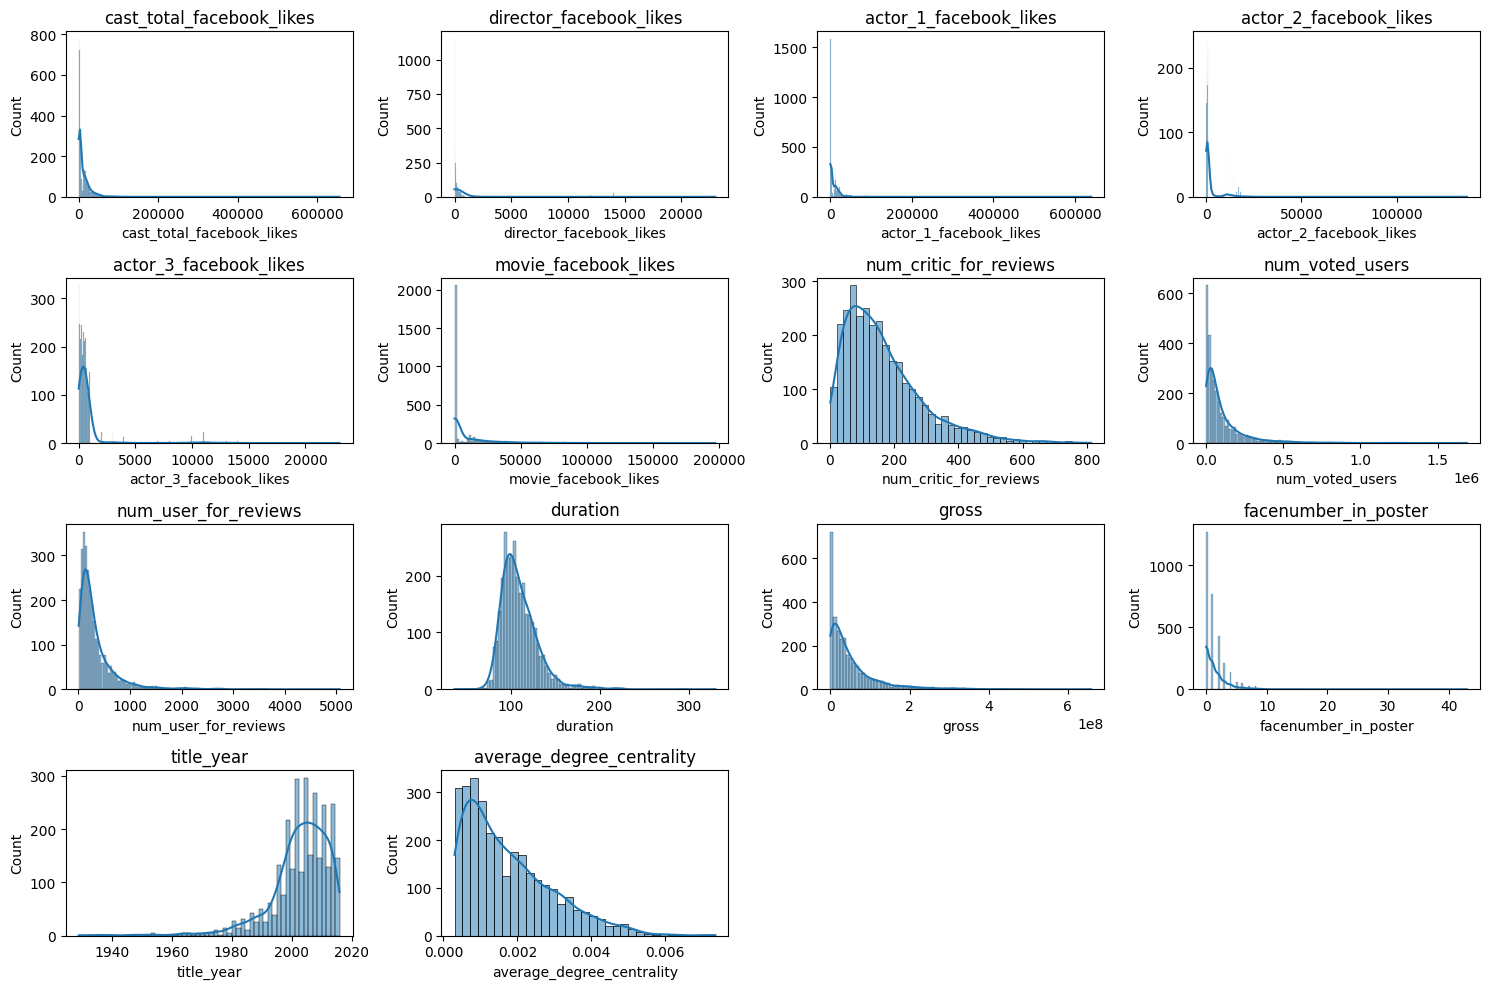

In [83]:
import seaborn as sns
import matplotlib.pyplot as plt

# features
features = ['cast_total_facebook_likes', 'director_facebook_likes', 
              'actor_1_facebook_likes', 'actor_2_facebook_likes', 
              'actor_3_facebook_likes', 'movie_facebook_likes',
              'num_critic_for_reviews', 'num_voted_users', 'num_user_for_reviews',
              'duration','gross','facenumber_in_poster','title_year','average_degree_centrality']

plt.figure(figsize=(15, 10))

for i, feature in enumerate(features):
    plt.subplot(4, 4, i+1)  
    sns.histplot(df[feature], kde=True)
    plt.title(feature)

# create the plot show the feature before log
plt.tight_layout()
plt.show()

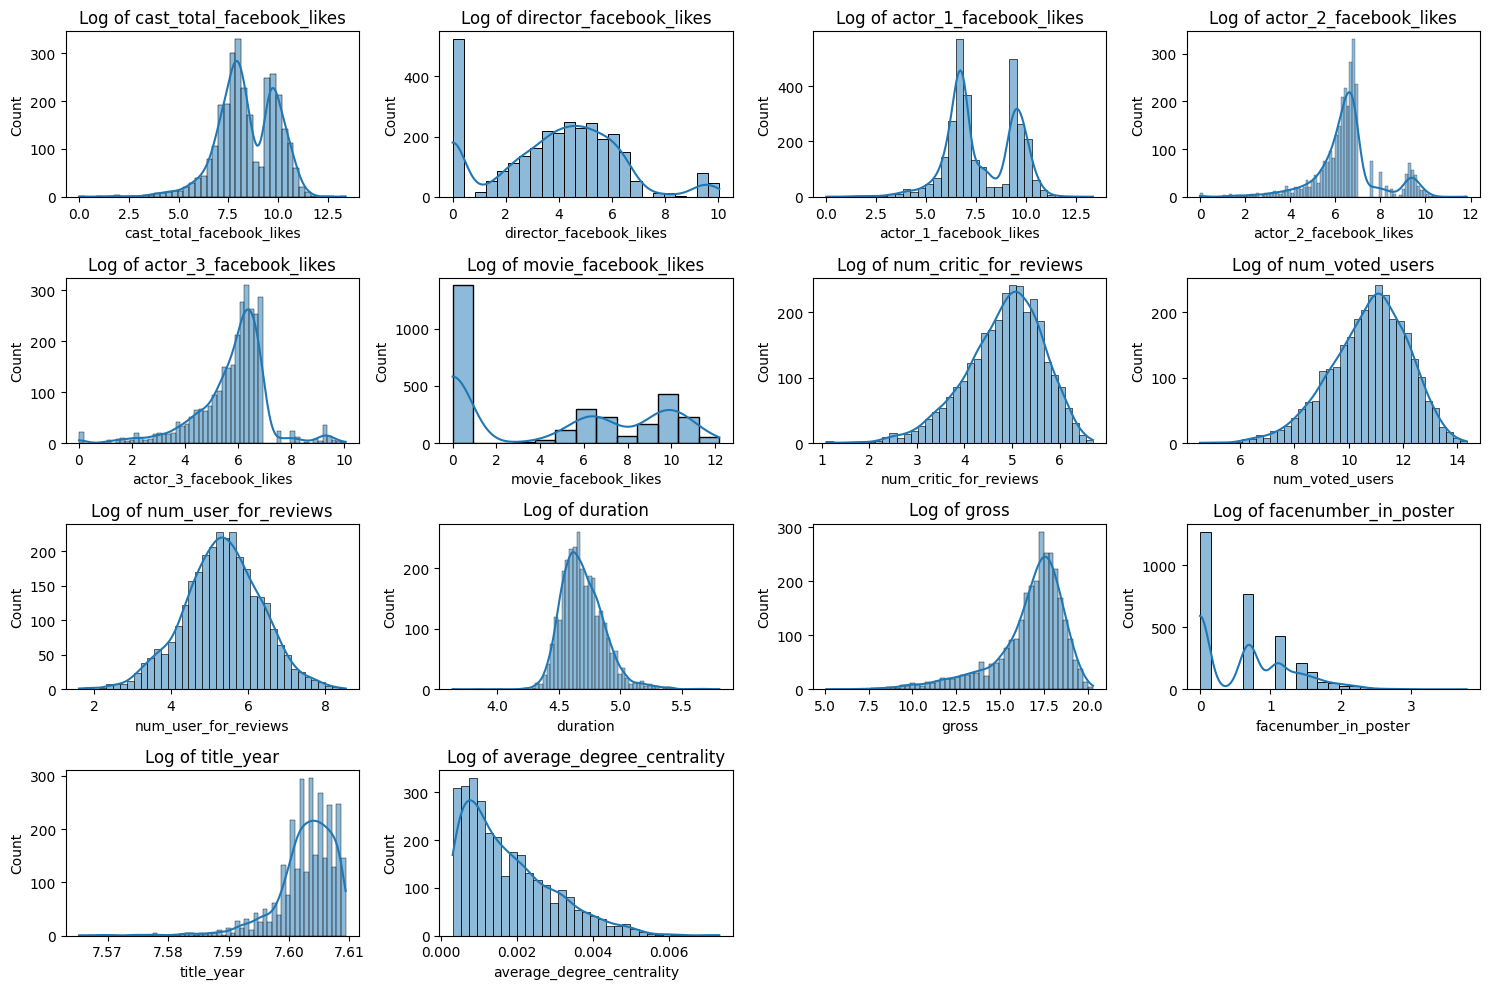

In [84]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd


features = ['cast_total_facebook_likes', 'director_facebook_likes', 
            'actor_1_facebook_likes', 'actor_2_facebook_likes', 
            'actor_3_facebook_likes', 'movie_facebook_likes',
            'num_critic_for_reviews', 'num_voted_users', 'num_user_for_reviews',
            'duration', 'gross', 'facenumber_in_poster', 'title_year', 'average_degree_centrality']


plt.figure(figsize=(15, 10))

# avoid 0 value problem
for i, feature in enumerate(features):
    plt.subplot(4, 4, i + 1) 
    log_values = np.log1p(df[feature])
    
    sns.histplot(log_values, kde=True)
    plt.title(f'Log of {feature}') 

# features after log
plt.tight_layout()
plt.show()


In [85]:
log_df = df
columns_to_log = [
    'movie_facebook_likes', 'director_facebook_likes', 'actor_1_facebook_likes',
    'cast_total_facebook_likes', 'actor_2_facebook_likes', 'actor_3_facebook_likes', 
    'facenumber_in_poster'
]


for column in columns_to_log:
    log_df[column] = np.log1p(log_df[column]) # value contain 0, use log1p

columns_to_log = [
    'num_voted_users', 'gross',
    'num_critic_for_reviews', 'num_user_for_reviews', 'average_degree_centrality'
]


for column in columns_to_log:
    log_df[column] = np.log(log_df[column])

In [86]:

columns = [
    'cast_total_facebook_likes',
    'director_facebook_likes',
    'actor_1_facebook_likes',
    'actor_2_facebook_likes',
    'actor_3_facebook_likes',
    'movie_facebook_likes',
    'num_critic_for_reviews',
    'num_voted_users',
    'num_user_for_reviews',
    'duration',
    'gross',
    'facenumber_in_poster',
    'title_year',
    'average_degree_centrality'
]


###  Mutual information

In [87]:
mi_scores = mutual_info_classif(log_df[columns], log_df['imdb_score_binned'], discrete_features=False)

# calculate MI 
mi_df = pd.DataFrame(mi_scores, index=columns, columns=['MI Score'])
mi_df = mi_df.sort_values(by='MI Score', ascending=False)
print(mi_df)

                           MI Score
num_voted_users            0.175846
movie_facebook_likes       0.107120
director_facebook_likes    0.092992
num_user_for_reviews       0.086739
num_critic_for_reviews     0.082404
duration                   0.069113
cast_total_facebook_likes  0.047807
actor_1_facebook_likes     0.035190
actor_3_facebook_likes     0.027627
actor_2_facebook_likes     0.025199
gross                      0.023063
title_year                 0.021107
average_degree_centrality  0.015312
facenumber_in_poster       0.005020


In [89]:
'''
cast_total_facebook_likes
director_facebook_likes
actor_1_facebook_likes
actor_2_facebook_likes
actor_3_facebook_likes
movie_facebook_likes

num_critic_for_reviews
num_voted_users
num_user_for_reviews

duration
gross
facenumber_in_poster
title_year
average_degree_centrality
'''

# calculate the average MI after 10 iteration
attributes = ['cast_total_facebook_likes', 'director_facebook_likes', 
              'actor_1_facebook_likes', 'actor_2_facebook_likes', 
              'actor_3_facebook_likes', 'movie_facebook_likes',
              'num_critic_for_reviews', 'num_voted_users', 'num_user_for_reviews',
              'duration','gross','facenumber_in_poster','title_year','average_degree_centrality']

num_iterations = 10
total_mi_scores = {attribute: 0 for attribute in attributes} 

for i in range(num_iterations):
    for attribute in attributes:
        X = df[[attribute]]
        y = df['imdb_score_binned']
        
        mi_scores = mutual_info_classif(X, y) 
        total_mi_scores[attribute] += mi_scores[0]  

average_mi_scores = {attribute: total_mi_scores[attribute] / num_iterations for attribute in attributes}
average_mi_df = pd.DataFrame(list(average_mi_scores.items()), columns=['Attribute', 'Average MI'])
print(average_mi_df.sort_values(by='Average MI', ascending=False))


                    Attribute  Average MI
7             num_voted_users    0.176051
5        movie_facebook_likes    0.101161
8        num_user_for_reviews    0.089217
1     director_facebook_likes    0.074155
6      num_critic_for_reviews    0.067438
9                    duration    0.057819
0   cast_total_facebook_likes    0.046399
2      actor_1_facebook_likes    0.043866
3      actor_2_facebook_likes    0.037820
13  average_degree_centrality    0.029242
4      actor_3_facebook_likes    0.027019
10                      gross    0.023034
12                 title_year    0.015178
11       facenumber_in_poster    0.004125


In [91]:
df.groupby('imdb_score_binned')['title_year'].describe()




,count,mean,std,min,25%,50%,75%,max
imdb_score_binned,,,,,,,,
0,24.0,2002.708333,6.003471,1986.0,2000.75,2004.5,2006.0,2011.0
1,235.0,2003.744681,7.285591,1980.0,2000.00,2004.0,2009.0,2016.0
2,1839.0,2003.629146,8.865120,1929.0,1999.00,2005.0,2010.0,2016.0
3,777.0,2001.845560,11.446169,1933.0,1998.00,2004.0,2009.0,2016.0
4,129.0,1994.627907,16.616102,1936.0,1986.00,1999.0,2007.0,2016.0


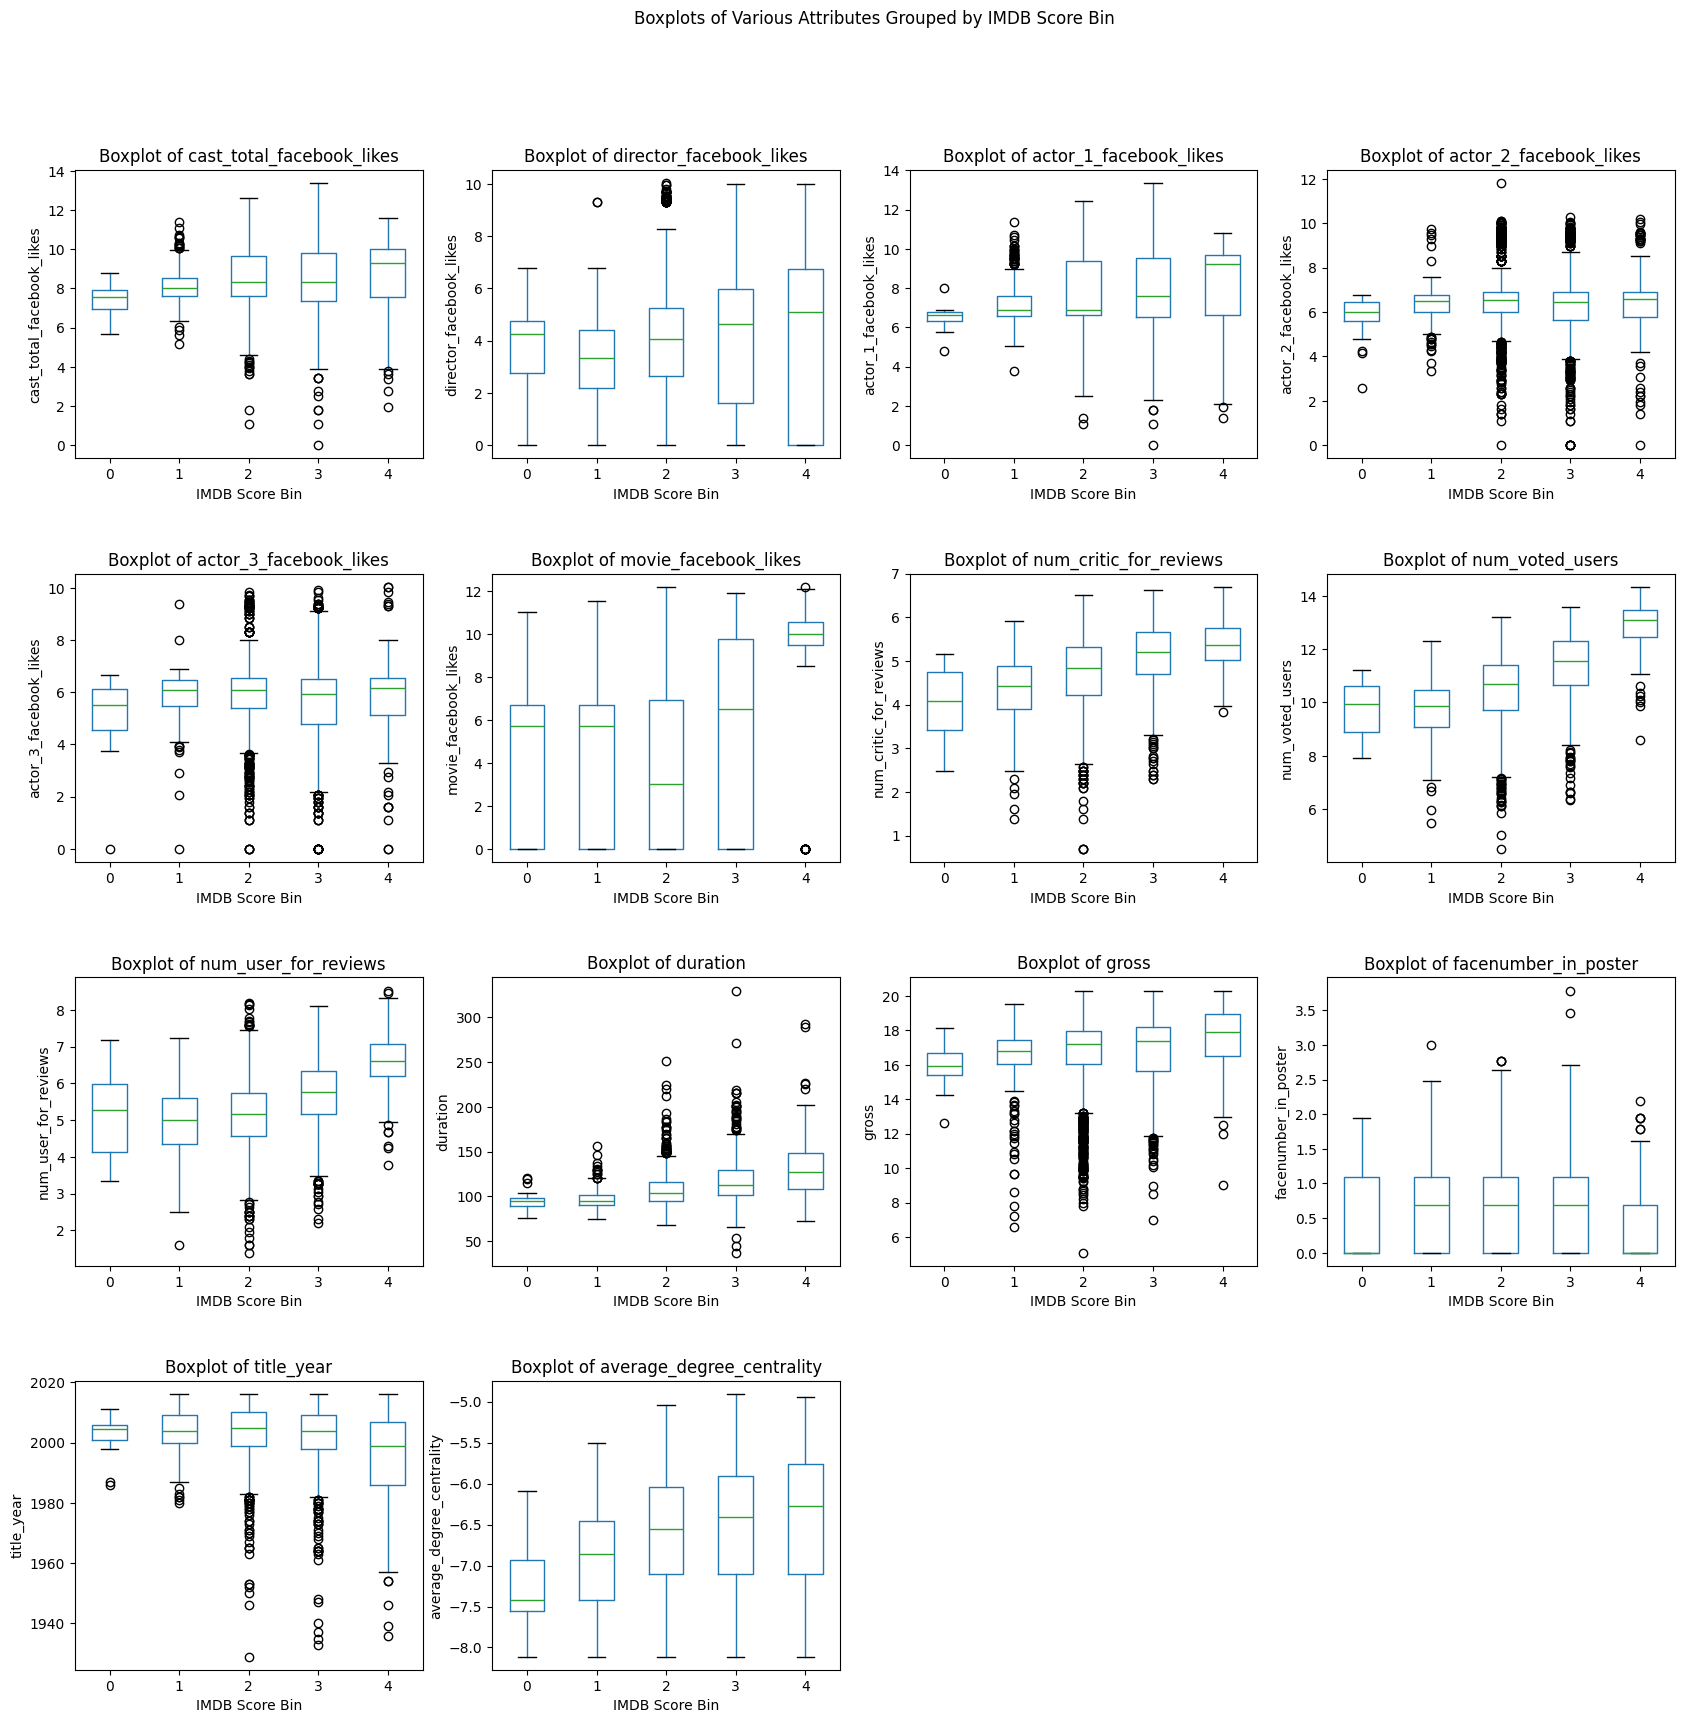

In [92]:
# draw the boxplot after log
attributes = ['cast_total_facebook_likes', 'director_facebook_likes', 
              'actor_1_facebook_likes', 'actor_2_facebook_likes', 
              'actor_3_facebook_likes', 'movie_facebook_likes',
              'num_critic_for_reviews', 'num_voted_users', 'num_user_for_reviews',
              'duration','gross','facenumber_in_poster','title_year','average_degree_centrality']


num_attributes = len(attributes)
num_columns = 4
num_rows = (num_attributes + num_columns - 1) // num_columns  

fig, axs = plt.subplots(num_rows, num_columns, figsize=(20, 5 * num_rows))  
fig.subplots_adjust(hspace=0.4, wspace=0.3) 

for i, attr in enumerate(attributes):
    ax = axs[i // num_columns, i % num_columns]  
    df.boxplot(column=attr, by='imdb_score_binned', ax=ax, grid=False)
    ax.set_title(f'Boxplot of {attr}')
    ax.set_xlabel('IMDB Score Bin')
    ax.set_ylabel(attr)


for j in range(i + 1, num_rows * num_columns):
    fig.delaxes(axs[j // num_columns, j % num_columns])

plt.suptitle('Boxplots of Various Attributes Grouped by IMDB Score Bin') 
plt.show()


In [93]:

df.groupby('imdb_score_binned')['facenumber_in_poster'].describe()

,count,mean,std,min,25%,50%,75%,max
imdb_score_binned,,,,,,,,
0,24.0,0.495231,0.607694,0.0,0.0,0.000000,1.098612,1.945910
1,235.0,0.628612,0.685316,0.0,0.0,0.693147,1.098612,2.995732
2,1839.0,0.688818,0.648826,0.0,0.0,0.693147,1.098612,2.772589
3,777.0,0.530052,0.611422,0.0,0.0,0.693147,1.098612,3.784190
4,129.0,0.490846,0.583979,0.0,0.0,0.000000,0.693147,2.197225


<Axes: title={'center': 'average_degree_centrality'}, xlabel='imdb_score_binned'>

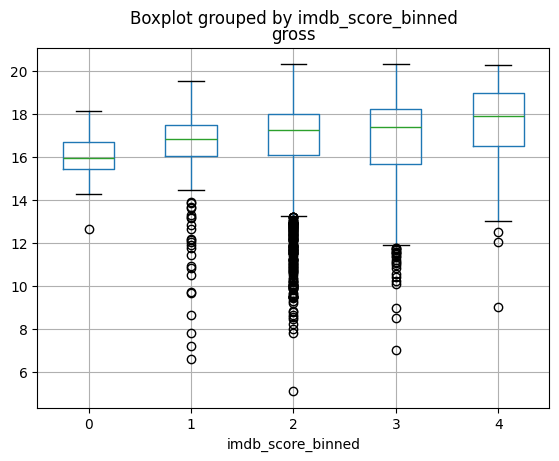

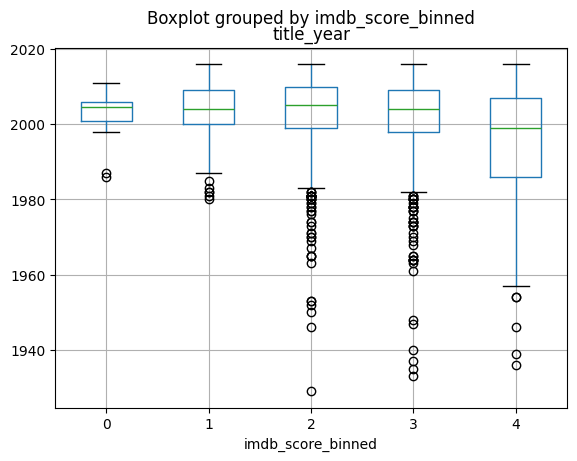

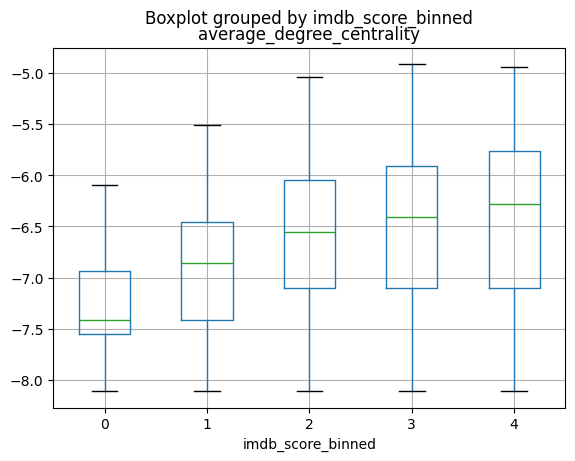

In [94]:

df.boxplot('gross',by='imdb_score_binned')
df.boxplot('title_year',by='imdb_score_binned')
df.boxplot('average_degree_centrality',by='imdb_score_binned')


In [95]:
df.groupby('imdb_score_binned')['director_facebook_likes'].describe()

,count,mean,std,min,25%,50%,75%,max
imdb_score_binned,,,,,,,,
0,24.0,3.831639,1.759103,0.0,2.743425,4.262680,4.759704,6.794587
1,235.0,3.121494,1.870164,0.0,2.197225,3.332205,4.388238,9.305741
2,1839.0,3.850644,2.153690,0.0,2.639057,4.077537,5.247024,10.043293
3,777.0,4.062064,2.837027,0.0,1.609438,4.624973,5.961005,9.998843
4,129.0,4.407714,3.624022,0.0,0.000000,5.087596,6.728629,9.998843


<Axes: title={'center': 'director_facebook_likes'}, xlabel='imdb_score_binned'>

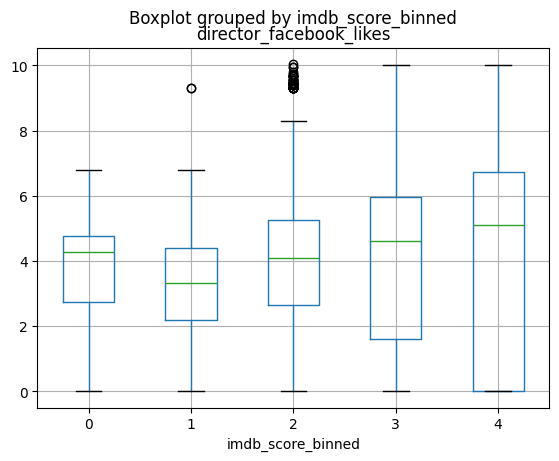

In [96]:
df.boxplot('director_facebook_likes',by='imdb_score_binned')

In [97]:
attributes = ['cast_total_facebook_likes',
    'director_facebook_likes',
    'actor_1_facebook_likes',
    'actor_2_facebook_likes',
    'actor_3_facebook_likes',
    'movie_facebook_likes',
    'num_critic_for_reviews',
    'num_voted_users',
    'num_user_for_reviews',
    'gross',
    'average_degree_centrality']
subset_data = df[attributes]

subset_data.describe()
subset_data.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3004 entries, 0 to 3003
Data columns (total 11 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   cast_total_facebook_likes  3004 non-null   float64
 1   director_facebook_likes    3004 non-null   float64
 2   actor_1_facebook_likes     3004 non-null   float64
 3   actor_2_facebook_likes     3004 non-null   float64
 4   actor_3_facebook_likes     3004 non-null   float64
 5   movie_facebook_likes       3004 non-null   float64
 6   num_critic_for_reviews     3004 non-null   float64
 7   num_voted_users            3004 non-null   float64
 8   num_user_for_reviews       3004 non-null   float64
 9   gross                      3004 non-null   float64
 10  average_degree_centrality  3004 non-null   float64
dtypes: float64(11)
memory usage: 258.3 KB


<Figure size 1200x1000 with 0 Axes>

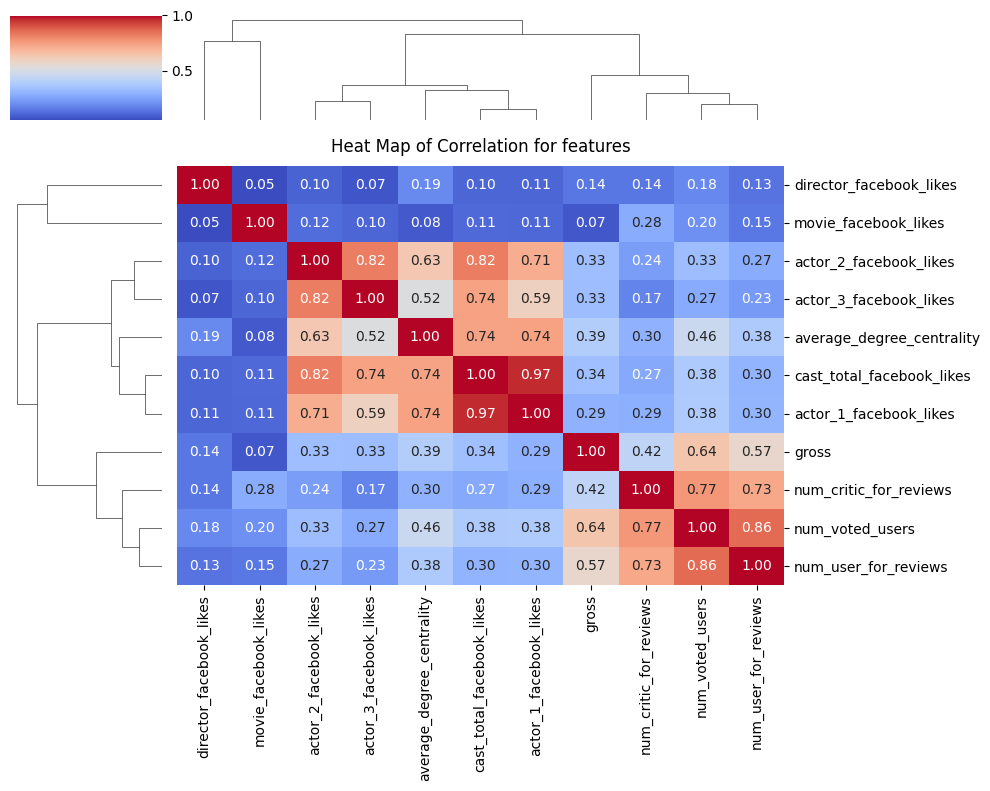

In [101]:
# Compute the correlation matrix
corr = subset_data.corr()

# Generate a mask for the upper triangle
mask = np.triu(np.ones_like(corr, dtype=bool))

# Set up the matplotlib figure
plt.figure(figsize=(12, 10))

# Draw the heatmap with the mask and correct aspect ratio
map = sns.clustermap(corr, annot=True, cmap='coolwarm', fmt=".2f", figsize=(10, 8))

map.ax_heatmap.set_title('Heat Map of Correlation for features', pad=10)
# Adjust layout
plt.tight_layout()
plt.show()



In [102]:
def calculate_mi(df):
    mi_matrix = pd.DataFrame(index=df.columns, columns=df.columns, dtype=float)
    for col in df.columns:
        for col2 in df.columns:
            mi_matrix.loc[col, col2] = mutual_info_regression(df[[col]], df[col2])[0]
    return mi_matrix

# Calculate and print MI matrix
mi_matrix = calculate_mi(subset_data)
mi_matrix

,cast_total_facebook_likes,director_facebook_likes,actor_1_facebook_likes,actor_2_facebook_likes,actor_3_facebook_likes,movie_facebook_likes,num_critic_for_reviews,num_voted_users,num_user_for_reviews,gross,average_degree_centrality
cast_total_facebook_likes,6.726449,0.089703,1.632884,0.954083,0.811270,0.074072,0.081609,0.126448,0.083762,0.095530,0.458955
director_facebook_likes,0.089686,4.962148,0.126486,0.058423,0.067763,0.081655,0.093972,0.170288,0.141622,0.088106,0.196024
actor_1_facebook_likes,1.634336,0.120699,4.890093,0.691408,0.429019,0.075974,0.077649,0.113458,0.083433,0.080421,0.496111
actor_2_facebook_likes,0.953151,0.055820,0.688265,5.830403,1.034121,0.041548,0.051587,0.092702,0.095386,0.064966,0.356696
actor_3_facebook_likes,0.812995,0.068784,0.426765,1.028674,6.246392,0.041586,0.035198,0.064055,0.063145,0.072698,0.238110
movie_facebook_likes,0.073753,0.061948,0.080508,0.038374,0.050865,3.447214,0.453608,0.456989,0.263850,0.161440,0.067068
num_critic_for_reviews,0.080976,0.094112,0.079848,0.049288,0.035463,0.469286,5.817429,0.500472,0.482366,0.128729,0.073564
num_voted_users,0.126517,0.170752,0.110835,0.093054,0.062829,0.456706,0.500879,6.747810,0.731388,0.354762,0.129175
num_user_for_reviews,0.084196,0.143278,0.081844,0.096561,0.062369,0.263121,0.484033,0.731573,6.195578,0.254111,0.103193
gross,0.095443,0.088546,0.079963,0.064883,0.071852,0.159672,0.127894,0.354723,0.253512,6.746256,0.121904


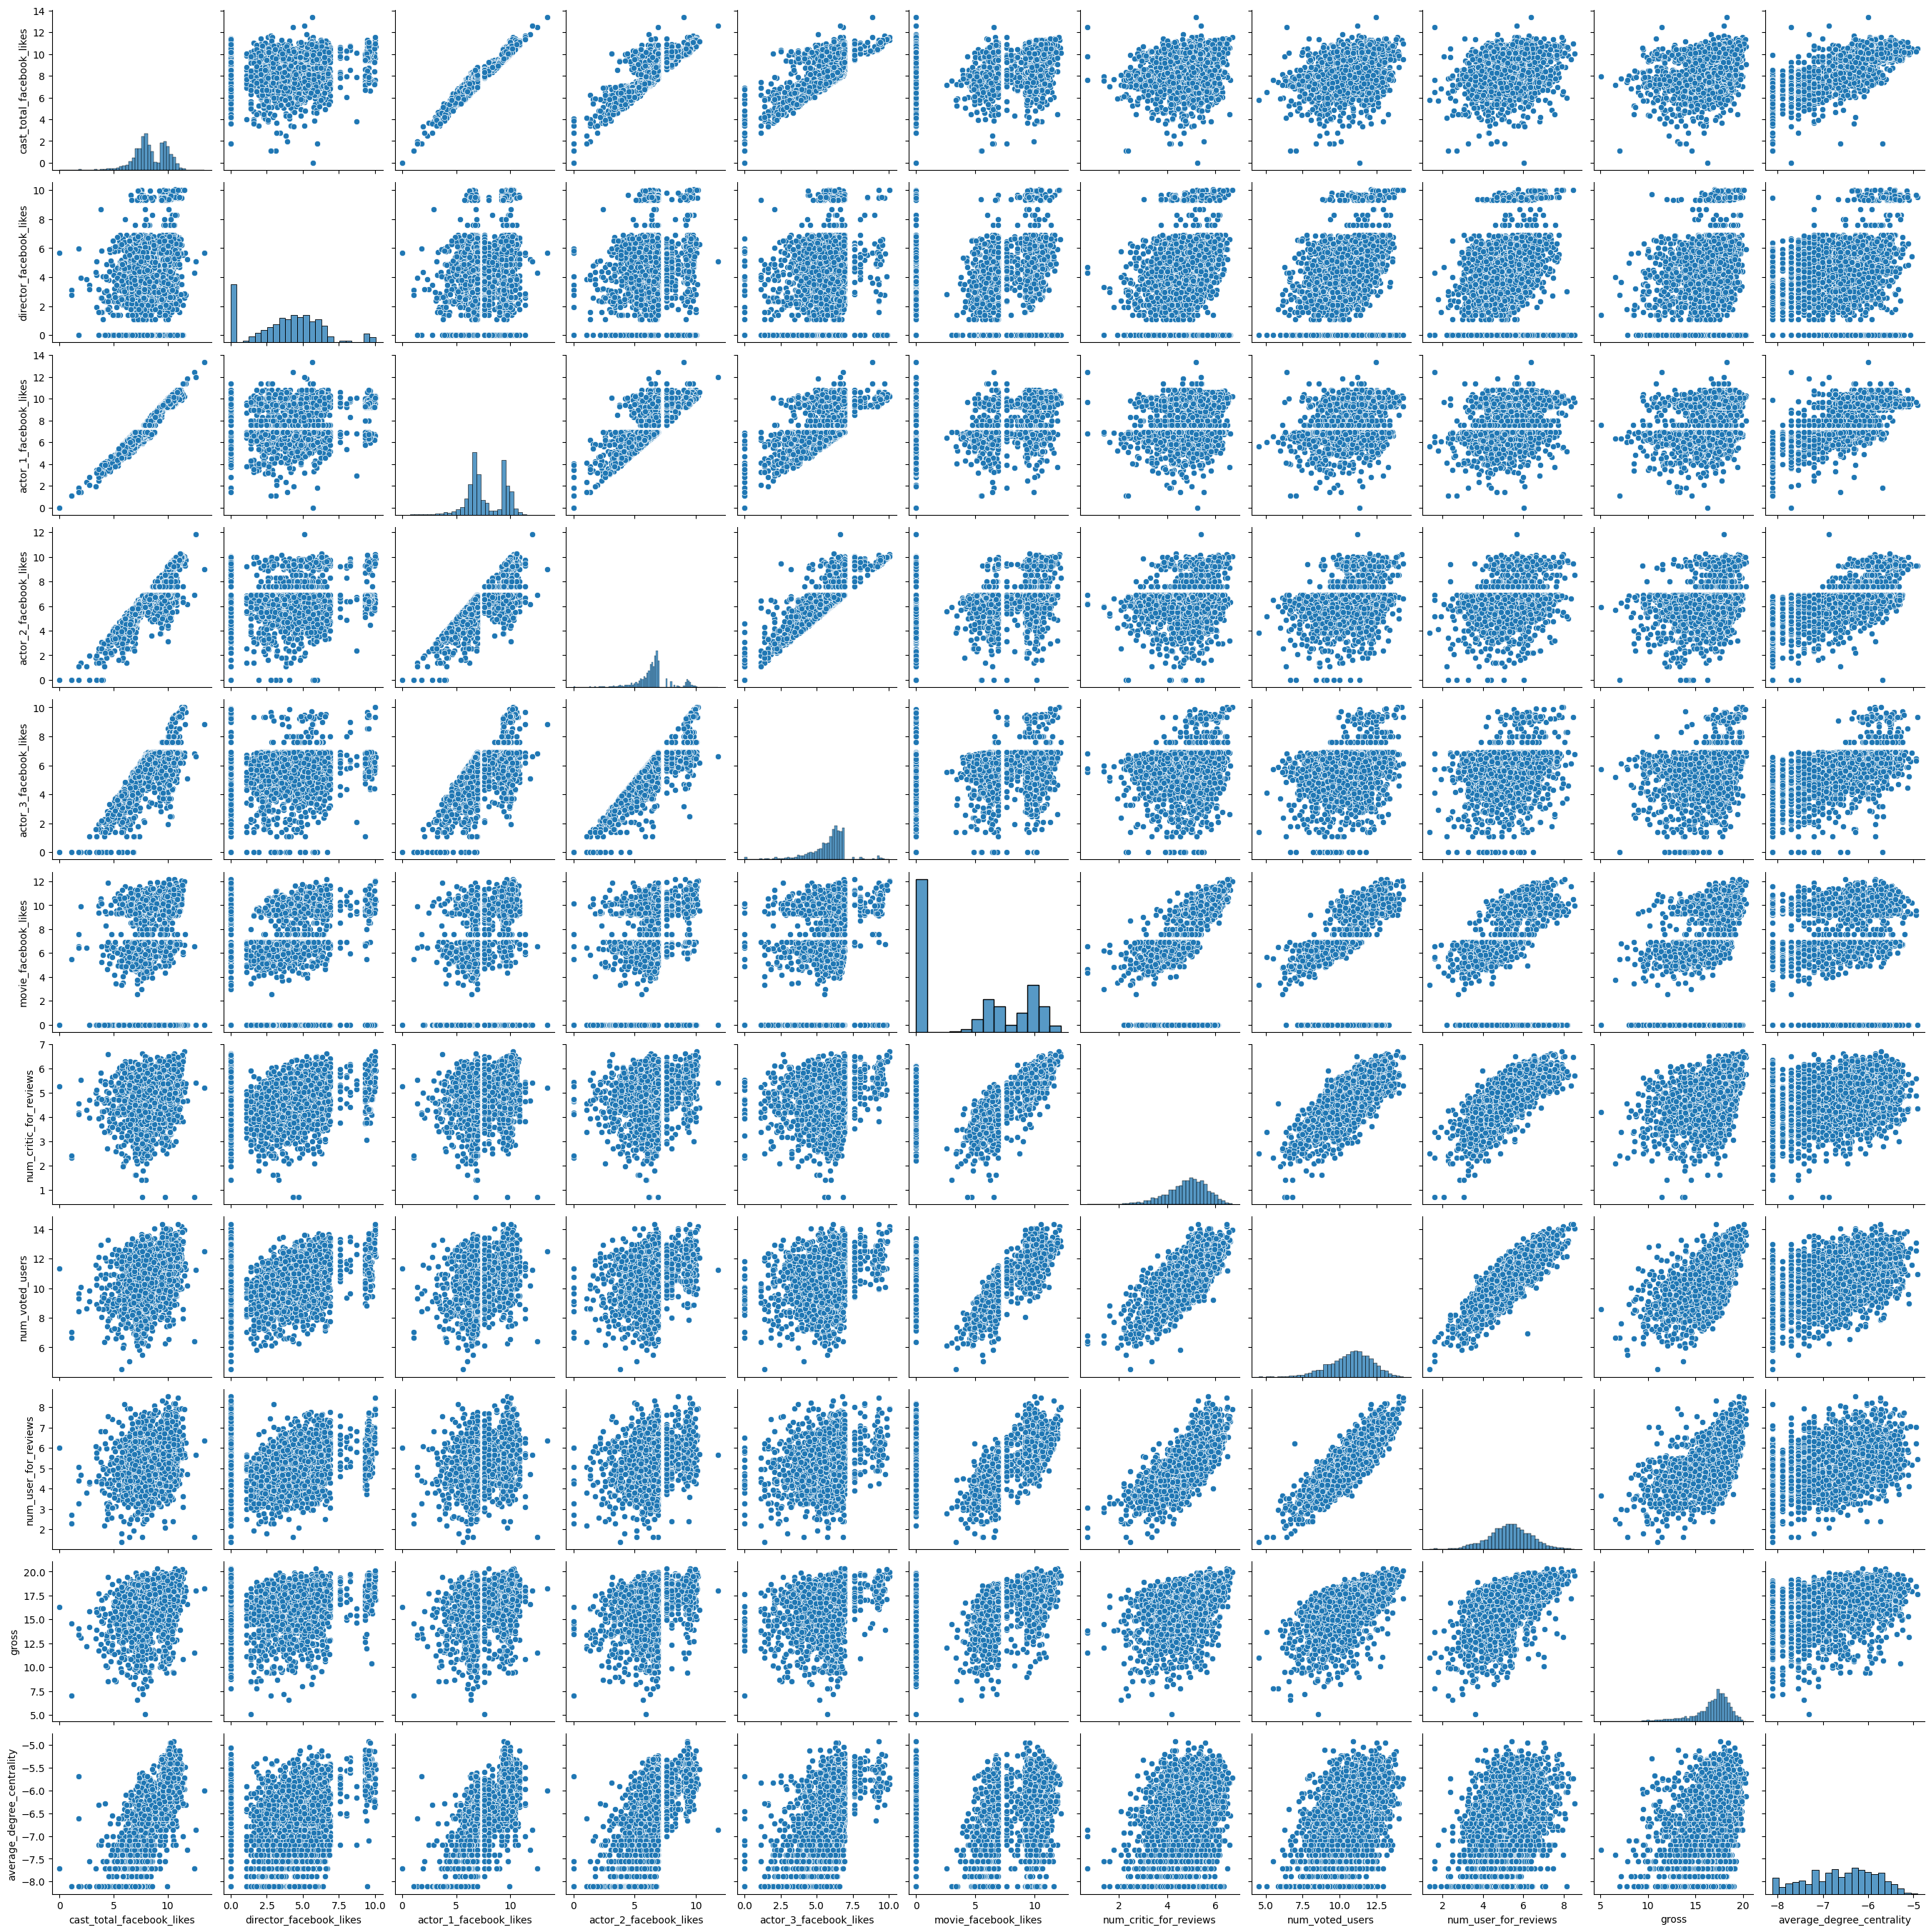

In [103]:
sns.pairplot(subset_data)


Model Accuracy: 0.7261640798226164
Feature importances:
 num_voted_users              0.176019
title_year                   0.088774
gross                        0.076018
duration                     0.074884
movie_facebook_likes         0.065542
num_user_for_reviews         0.064609
actor_3_facebook_likes       0.060895
average_degree_centrality    0.059989
director_facebook_likes      0.059677
num_critic_for_reviews       0.059069
actor_2_facebook_likes       0.055941
cast_total_facebook_likes    0.054392
actor_1_facebook_likes       0.053018
facenumber_in_poster         0.051173
dtype: float32


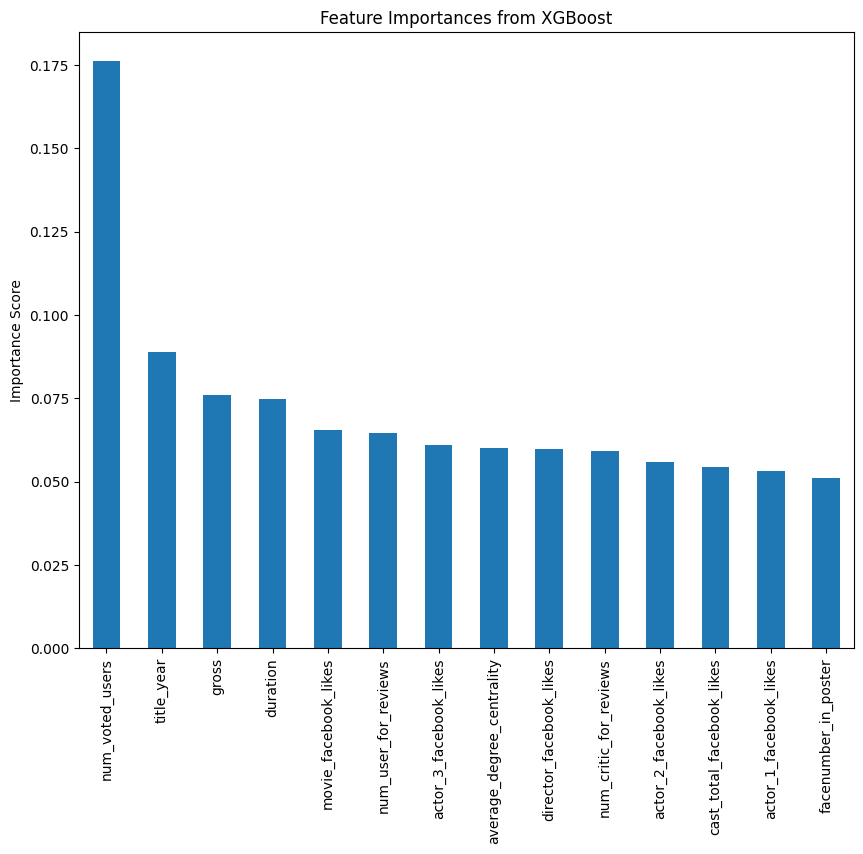

In [104]:


import xgboost as xgb
original_attributes = [
    'cast_total_facebook_likes',
    'director_facebook_likes',
    'actor_1_facebook_likes',
    'actor_2_facebook_likes',
    'actor_3_facebook_likes',
    'movie_facebook_likes',
    'num_critic_for_reviews',
    'num_voted_users',
    'num_user_for_reviews',
    'duration',
    'gross',
    'facenumber_in_poster',
    'title_year',
    'average_degree_centrality'
]


X = df[original_attributes]
y = df['imdb_score_binned']

# train and test dataset
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)
# xgboost
xgb_clf = xgb.XGBClassifier(objective='multi:softprob', n_estimators=100, random_state=42)

# train
xgb_clf.fit(X_train, y_train)

from sklearn.metrics import accuracy_score

# predict
y_pred = xgb_clf.predict(X_test)

# calculate accurancy
accuracy = accuracy_score(y_test, y_pred)


print("Model Accuracy:", accuracy)
# get feature importance
importances = xgb_clf.feature_importances_
feature_importances = pd.Series(importances, index=features)

# print
print("Feature importances:\n", feature_importances.sort_values(ascending=False))

# plot
plt.figure(figsize=(10, 8))
feature_importances.sort_values(ascending=False).plot(kind='bar')
plt.title('Feature Importances from XGBoost')
plt.ylabel('Importance Score')
plt.show()

In [105]:
mean_importance = feature_importances.mean()
selected_features = feature_importances[feature_importances > mean_importance].index

print("Selected features:", selected_features)

X_train_selected = X_train[selected_features]
X_test_selected = X_test[selected_features]

xgb_clf_selected = xgb.XGBClassifier(objective='multi:softprob', n_estimators=100, random_state=42)
xgb_clf_selected.fit(X_train_selected, y_train)

predictions = xgb_clf_selected.predict(X_test_selected)
accuracy = accuracy_score(y_test, predictions)
print("Accuracy with selected features: %.2f%%" % (accuracy * 100.0))

Selected features: Index(['num_voted_users', 'duration', 'gross', 'title_year'], dtype='object')
Accuracy with selected features: 65.52%


### object data

In [106]:
df_object = pd.read_csv('project_data/train_dataset.csv', encoding='utf-8')

In [107]:
# country language
language_df = pd.DataFrame()
country_df = pd.DataFrame()
language_df['is_english'] = df_object['language'].apply(lambda x: 1 if x == 'English' else 0)
country_df['is_usa'] = df_object['country'].apply(lambda x: 1 if x == 'USA' else 0)

In [108]:
# content rating

from sklearn.preprocessing import OneHotEncoder


# OneHotEncoder
encoder = OneHotEncoder(sparse_output=False)
ratings_encoded = encoder.fit_transform(df_object[['content_rating']])

feature_names = encoder.get_feature_names_out(['content_rating'])

# change to DataFrame
encoded_cr = pd.DataFrame(ratings_encoded, columns=feature_names)
encoded_cr

,content_rating_Approved,content_rating_G,content_rating_GP,content_rating_M,content_rating_NC-17,content_rating_Not Rated,content_rating_PG,content_rating_PG-13,content_rating_Passed,content_rating_R,content_rating_Unrated,content_rating_X
0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...
2999,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
3000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
3001,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
3002,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0


In [109]:
import numpy as np
title_embedding = pd.DataFrame(np.load(r'project_data/features_fasttext/train_fasttext_title_embeddings.npy'))
genre_df = pd.DataFrame(np.load(r'project_data/features_doc2vec/train_doc2vec_features_genre.npy'))
keyword_df = pd.DataFrame(np.load(r'project_data/features_doc2vec/train_doc2vec_features_plot_keywords.npy'))
director_df = pd.DataFrame(np.load(r'project_data/features_countvec/train_countvec_features_director_name.npy'))
actor1_df = pd.DataFrame(np.load(r'project_data/features_countvec/train_countvec_features_actor_1_name.npy'))
actor2_df = pd.DataFrame(np.load(r'project_data/features_countvec/train_countvec_features_actor_2_name.npy'))


In [110]:
from sklearn.feature_extraction.text import CountVectorizer
vectorizer = CountVectorizer()
actor3 = vectorizer.fit_transform(df_object['actor_3_name'])
actor3_df = pd.DataFrame(actor3.toarray(), columns=vectorizer.get_feature_names_out())
actor3_df

,aaliyah,aaron,aasif,abadie,abbie,abby,abdalla,aboulafia,abraham,abtahi,...,zima,zinedine,zinta,zoe,zooey,zoë,zylka,ángel,óscar,ølgaard
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2999,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3000,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3001,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3002,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [111]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier


def evaluate_datasets(features_datasets, labels, test_size=0.25, random_state=42):
    results = []
    
    # ensure pandas series
    if not isinstance(labels, pd.Series):
        labels = pd.Series(labels)
    
    for name, df in features_datasets.items():
        X_train, X_ver, y_train, y_ver = train_test_split(df, labels, test_size=test_size, random_state=random_state)
        
        model = RandomForestClassifier(
            n_estimators=300,
            max_depth=18,
            min_samples_leaf=5,
            min_samples_split=10,
            max_features='sqrt',
            random_state=random_state
        )
        model.fit(X_train, y_train)
        
        train_accuracy = model.score(X_train, y_train)
        validation_accuracy = model.score(X_ver, y_ver)
        
        results.append({
            'Dataset': name,
            'Train Accuracy': train_accuracy,
            'Validation Accuracy': validation_accuracy
        })
    
    # sort by accurancy
    results.sort(key=lambda x: x['Validation Accuracy'], reverse=True)
    
    return results


datasets = {
    'title': title_embedding,
    'language': language_df,
    'country': country_df,
    'genre': genre_df,
    'plot_keywords': keyword_df,
    'director_name': director_df,
    'actor_name_1': actor3_df,
    'actor_name_2':actor2_df,
    'actor_name_3': actor3_df,
    'content-rating': encoded_cr

}

labels = df_object['imdb_score_binned']  

results = evaluate_datasets(datasets, labels)
for result in results:
    print(result)


{'Dataset': 'genre', 'Train Accuracy': 0.7989347536617842, 'Validation Accuracy': 0.6484687083888149}
{'Dataset': 'language', 'Train Accuracy': 0.6222814025743453, 'Validation Accuracy': 0.6338215712383488}
{'Dataset': 'title', 'Train Accuracy': 0.8415446071904128, 'Validation Accuracy': 0.6271637816245007}
{'Dataset': 'plot_keywords', 'Train Accuracy': 0.8610741233910342, 'Validation Accuracy': 0.6191744340878829}
{'Dataset': 'country', 'Train Accuracy': 0.6120727918331114, 'Validation Accuracy': 0.6125166444740346}
{'Dataset': 'director_name', 'Train Accuracy': 0.6120727918331114, 'Validation Accuracy': 0.6125166444740346}
{'Dataset': 'actor_name_1', 'Train Accuracy': 0.6120727918331114, 'Validation Accuracy': 0.6125166444740346}
{'Dataset': 'actor_name_2', 'Train Accuracy': 0.6120727918331114, 'Validation Accuracy': 0.6125166444740346}
{'Dataset': 'actor_name_3', 'Train Accuracy': 0.6120727918331114, 'Validation Accuracy': 0.6125166444740346}
{'Dataset': 'content-rating', 'Train Acc

# Preprocess 

## Method 1

In [112]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import OneHotEncoder

def create_dataframe_from_array(data_array, column_prefix):
    """从数组创建DataFrame并生成列名"""
    data_df = pd.DataFrame(data_array)
    new_columns = ['{}{}'.format(column_prefix, i + 1) for i in range(data_df.shape[1])]
    data_df.columns = new_columns
    return data_df

def preprocess_data(file_path, genre_path, plot_path, title_path):
    # read data
    df = pd.read_csv(file_path, encoding='utf-8')

    # for preprocessing language and country, binaryb coding
    if df['language'].dtype == 'object':
        df['language'] = df['language'].apply(lambda x: 1 if x == 'English' else 0)
    if df['country'].dtype == 'object':
        df['country'] = df['country'].apply(lambda x: 1 if x == 'USA' else 0)

    # cantecate the dataset
    genre_embed = np.load(genre_path)
    plot_embed = np.load(plot_path)
    title_embed = np.load(title_path)
    genre_df = create_dataframe_from_array(genre_embed, 'genre')
    plot_df = create_dataframe_from_array(plot_embed, 'plot')
    title_df = create_dataframe_from_array(title_embed, 'title')

    # one hot coding for content reating
    encoder = OneHotEncoder(sparse_output=False)
    ratings_encoded = encoder.fit_transform(df[['content_rating']])
    feature_names = encoder.get_feature_names_out(['content_rating'])
    encoded_cr = pd.DataFrame(ratings_encoded, columns=feature_names)

    # combine them
    combined_df = pd.concat([df, genre_df, plot_df, title_df, encoded_cr], axis=1)

    return combined_df

# usage
train_file_path = 'project_data/train_dataset.csv'
train_genre_path = 'project_data/features_doc2vec/train_doc2vec_features_genre.npy'
train_plot_path = 'project_data/features_doc2vec/train_doc2vec_features_plot_keywords.npy'
train_title_path = 'project_data/features_fasttext/train_fasttext_title_embeddings.npy'

train_df_combined = preprocess_data(train_file_path, train_genre_path, train_plot_path, train_title_path)

In [113]:
train_df_combined

,id,director_name,num_critic_for_reviews,duration,director_facebook_likes,actor_3_facebook_likes,actor_2_name,actor_1_facebook_likes,gross,genres,...,content_rating_GP,content_rating_M,content_rating_NC-17,content_rating_Not Rated,content_rating_PG,content_rating_PG-13,content_rating_Passed,content_rating_R,content_rating_Unrated,content_rating_X
0,1,Roger Allers,186,73,28,847,Nathan Lane,2000,422783777,Adventure|Animation|Drama|Family|Musical,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,2,George A. Romero,252,97,0,233,Shawn Roberts,654,20433940,Horror,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
2,3,David Gordon Green,232,117,234,221,Tye Sheridan,12000,371897,Drama,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
3,4,John Carpenter,297,109,0,145,Richard Masur,957,13782838,Horror|Mystery|Sci-Fi,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
4,5,Peter Jackson,297,171,0,857,Orlando Bloom,16000,313837577,Action|Adventure|Drama|Fantasy,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2999,3000,Ken Kwapis,161,129,42,49,Sabrina Revelle,97,93952276,Comedy|Drama|Romance,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
3000,3001,Ron Howard,393,123,2000,471,Olivia Wilde,26000,26903709,Action|Biography|Drama|Sport,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
3001,3002,F. Gary Gray,216,118,473,963,Leslie Bibb,18000,73343413,Crime|Drama|Thriller,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
3002,3003,Nadine Labaki,109,95,0,0,Adel Karam,227,1060591,Comedy|Drama|Romance,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0


In [114]:
# log transformation
log_train_com_df = train_df_combined
columns_to_log = [
    'movie_facebook_likes', 'director_facebook_likes', 'actor_1_facebook_likes',
    'cast_total_facebook_likes', 'actor_2_facebook_likes', 'actor_3_facebook_likes', 
    'facenumber_in_poster'
]

for column in columns_to_log:
    log_train_com_df[column] = np.log1p(log_train_com_df[column]) # 数值中含有0，用log1p

In [115]:
columns_to_log = [
    'num_voted_users', 'gross',
    'num_critic_for_reviews', 'num_user_for_reviews', 'average_degree_centrality'
]

# log transformation
for column in columns_to_log:
    log_train_com_df[column] = np.log(log_train_com_df[column]) # 数值中不有0，用log


log_train_com_df # df after log transformation

,id,director_name,num_critic_for_reviews,duration,director_facebook_likes,actor_3_facebook_likes,actor_2_name,actor_1_facebook_likes,gross,genres,...,content_rating_GP,content_rating_M,content_rating_NC-17,content_rating_Not Rated,content_rating_PG,content_rating_PG-13,content_rating_Passed,content_rating_R,content_rating_Unrated,content_rating_X
0,1,Roger Allers,5.225747,73,3.367296,6.742881,Nathan Lane,7.601402,19.862371,Adventure|Animation|Drama|Family|Musical,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,2,George A. Romero,5.529429,97,0.000000,5.455321,Shawn Roberts,6.484635,16.832708,Horror,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
2,3,David Gordon Green,5.446737,117,5.459586,5.402677,Tye Sheridan,9.392745,12.826372,Drama,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
3,4,John Carpenter,5.693732,109,0.000000,4.983607,Richard Masur,6.864848,16.438935,Horror|Mystery|Sci-Fi,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
4,5,Peter Jackson,5.693732,171,0.000000,6.754604,Orlando Bloom,9.680406,19.564386,Action|Adventure|Drama|Fantasy,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2999,3000,Ken Kwapis,5.081404,129,3.761200,3.912023,Sabrina Revelle,4.584967,18.358298,Comedy|Drama|Romance,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
3000,3001,Ron Howard,5.973810,123,7.601402,6.156979,Olivia Wilde,10.165890,17.107775,Action|Biography|Drama|Sport,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
3001,3002,F. Gary Gray,5.375278,118,6.161207,6.871091,Leslie Bibb,9.798183,18.110663,Crime|Drama|Thriller,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
3002,3003,Nadine Labaki,4.691348,95,0.000000,0.000000,Adel Karam,5.429346,13.874337,Comedy|Drama|Romance,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0


## Method 2

In [116]:
from joblib import dump
# save model on computer
def save_model(model, feature_name):
    filename = f"{feature_name}_model.joblib"
    dump(model, filename)


In [117]:
from joblib import load
# load the saved model and traning on test data
def load_model(feature_name):
    filename = f"{feature_name}_model.joblib"
    try:
        model = load(filename)
    except FileNotFoundError:
        print(f"can't find {filename}。ensure your path。")
        model = None
    return model


In [118]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, cross_val_predict, cross_val_score
from sklearn.preprocessing import OneHotEncoder

def preprocess_ensemble(file_path, genre_path, plot_path, title_path, is_train=True):
    df = pd.read_csv(file_path, encoding='utf-8')
    # binary coding for language and country
    if df['language'].dtype == 'object':
        df['encode_language'] = df['language'].apply(lambda x: 1 if x == 'English' else 0)
    if df['country'].dtype == 'object':
        df['encode_country'] = df['country'].apply(lambda x: 1 if x == 'USA' else 0)
    # change to df
    language_df = df['encode_language'].to_frame()
    country_df = df['encode_country'].to_frame()
    # load embedding df
    genre_df = pd.DataFrame(np.load(genre_path))
    plot_df = pd.DataFrame(np.load(plot_path))
    title_df = pd.DataFrame(np.load(title_path))


    if is_train:
        # encoding for traning data
        encoder = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
        ratings_encoded = encoder.fit_transform(df[['content_rating']])
        
        feature_names = encoder.get_feature_names_out(['content_rating'])
        encoded_cr = pd.DataFrame(ratings_encoded, columns=feature_names)
        dump(encoder, 'content_rating_encoder.joblib')
    else:
        # encoding for test data
        encoder = load('content_rating_encoder.joblib')
        ratings_encoded = encoder.transform(df[['content_rating']])
        feature_names = encoder.get_feature_names_out(['content_rating'])
        encoded_cr = pd.DataFrame(ratings_encoded, columns=feature_names)



    if is_train:
        # train the model by using the training data
        train_predict_feature(df, 'country', 'imdb_score_binned', country_df)
        train_predict_feature(df, 'language', 'imdb_score_binned', language_df)
        train_predict_feature(df, 'content_rating', 'imdb_score_binned', encoded_cr)
        train_predict_feature(df, 'movie_title', 'imdb_score_binned', title_df)
        train_predict_feature(df, 'plot_keywords', 'imdb_score_binned', plot_df)
        train_predict_feature(df, 'genres', 'imdb_score_binned', genre_df)
    else:
        # For test data, directly use the trained model and transformation to make predictions
     
        apply_model_and_transform(df, 'country', country_df)
        apply_model_and_transform(df, 'language', language_df)
        apply_model_and_transform(df, 'content_rating', encoded_cr)
        apply_model_and_transform(df, 'genres', genre_df)
        apply_model_and_transform(df, 'plot_keywords', plot_df)
        apply_model_and_transform(df, 'movie_title', title_df)

    return df


def apply_model_and_transform(df, feature_name, encoder_df):
    # This function is only called during prediction, applying the previously trained model and converter
    # load model
    rf = load_model(feature_name) 
    predictions = rf.predict(encoder_df)
    if df[feature_name].dtype == 'object':
        df[feature_name] = predictions


In [119]:
def train_predict_feature(df, feature_name, target_name, encoder_df, n_estimators=300, max_depth=18, min_samples_leaf=5, min_samples_split=10, random_state=42, test_size=0.25, cv=5):
    # split train test
    X_train, X_ver, y_train, y_ver = train_test_split(encoder_df, df[target_name], test_size=test_size, random_state=random_state)
    
    # use RF model
    rf = RandomForestClassifier(
        n_estimators=n_estimators,
        max_depth=max_depth,
        min_samples_leaf=min_samples_leaf,
        min_samples_split=min_samples_split,
        random_state=random_state,
        n_jobs= -1
    )
    
    # train
    rf.fit(X_train, y_train)
    # save model
    save_model(rf, feature_name)
    
    # calculate val and acc score
    train_score = rf.score(X_train, y_train)
    verification_score = rf.score(X_ver, y_ver)
    
    # Make cross-validated predictions and scores
    cv_preds = cross_val_predict(rf, encoder_df, df[target_name], cv=cv, n_jobs=-1)
    cv_scores = cross_val_score(rf, encoder_df, df[target_name], cv=cv, scoring='accuracy', n_jobs=-1)
    
    # Replace original features
    if df[feature_name].dtype == 'object':
        df[feature_name] = cv_preds
    
    # Returns the model score and cross-validation mean score
    return train_score, verification_score, cv_scores.mean()

In [120]:

file_path = 'project_data/train_dataset.csv'
genre_path = 'project_data/features_doc2vec/train_doc2vec_features_genre.npy'
plot_path = 'project_data/features_doc2vec/train_doc2vec_features_plot_keywords.npy'
title_path = 'project_data/features_fasttext/train_fasttext_title_embeddings.npy'


train_df_ensem = preprocess_ensemble(file_path, genre_path, plot_path, title_path, is_train=True)




In [121]:
train_df_ensem['movie_title']

0       2
1       2
2       2
3       2
4       3
       ..
2999    2
3000    3
3001    2
3002    2
3003    2
Name: movie_title, Length: 3004, dtype: int64

In [122]:
log_ensem_train_df = train_df_ensem
columns_to_log = [
    'movie_facebook_likes', 'director_facebook_likes', 'actor_1_facebook_likes',
    'cast_total_facebook_likes', 'actor_2_facebook_likes', 'actor_3_facebook_likes', 
    'facenumber_in_poster'
]

# Apply log1p transformation to the specified column and replace the original column
for column in columns_to_log:
    log_ensem_train_df[column] = np.log1p(log_ensem_train_df[column])

In [123]:
columns_to_log = [
    'num_voted_users', 'gross',
    'num_critic_for_reviews', 'num_user_for_reviews', 'average_degree_centrality'
]

# Apply log transformation to the specified column and replace the original column
for column in columns_to_log:
    log_ensem_train_df[column] = np.log(log_ensem_train_df[column]) 


log_ensem_train_df 

,id,director_name,num_critic_for_reviews,duration,director_facebook_likes,actor_3_facebook_likes,actor_2_name,actor_1_facebook_likes,gross,genres,...,country,content_rating,title_year,actor_2_facebook_likes,movie_facebook_likes,title_embedding,average_degree_centrality,imdb_score_binned,encode_language,encode_country
0,1,Roger Allers,5.225747,73,3.367296,6.742881,Nathan Lane,7.601402,19.862371,2,...,2,2,1994,6.787845,9.741027,[-4.1984697e-03 4.2941985e-03 -1.1961063e-03 ...,-6.452950,4,1,1
1,2,George A. Romero,5.529429,97,0.000000,5.455321,Shawn Roberts,6.484635,16.832708,2,...,2,2,2005,6.272877,0.000000,[-4.7586653e-03 2.6511205e-03 -3.7954253e-04 ...,-7.300248,2,1,0
2,3,David Gordon Green,5.446737,117,5.459586,5.402677,Tye Sheridan,9.392745,12.826372,3,...,2,2,2013,6.908755,9.305741,[ 2.78131524e-03 -3.15494463e-03 -6.38332494e-...,-5.808593,2,1,1
3,4,John Carpenter,5.693732,109,0.000000,4.983607,Richard Masur,6.864848,16.438935,2,...,2,2,1982,5.099866,10.043293,[-5.32674184e-03 3.60742491e-03 7.91795843e-...,-6.361978,4,1,1
4,5,Peter Jackson,5.693732,171,0.000000,6.754604,Orlando Bloom,9.680406,19.564386,2,...,2,2,2001,8.517393,9.952325,[-4.2586620e-03 3.6257182e-03 -1.5326265e-03 ...,-6.278596,4,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2999,3000,Ken Kwapis,5.081404,129,3.761200,3.912023,Sabrina Revelle,4.584967,18.358298,2,...,2,2,2009,3.931826,9.392745,[-2.3482253e-03 4.0821606e-04 -4.6702172e-04 ...,-7.194887,2,1,1
3000,3001,Ron Howard,5.973810,123,7.601402,6.156979,Olivia Wilde,10.165890,17.107775,2,...,2,2,2013,9.210440,11.326608,[ 1.6231873e-03 -4.9172580e-04 3.6536737e-03 ...,-5.713283,4,1,0
3001,3002,F. Gary Gray,5.375278,118,6.161207,6.871091,Leslie Bibb,9.798183,18.110663,2,...,2,2,2009,6.908755,9.952325,[-1.0675089e-03 1.7000491e-03 -2.9880603e-04 ...,-5.713283,3,1,1
3002,3003,Nadine Labaki,4.691348,95,0.000000,0.000000,Adel Karam,5.429346,13.874337,2,...,2,2,2007,1.609438,0.000000,[-1.28144643e-03 -1.88259745e-03 1.82478712e-...,-8.111178,3,0,0


## Modeling

### KNN

#### Hold out try

In [124]:
log_ensem_train_df

,id,director_name,num_critic_for_reviews,duration,director_facebook_likes,actor_3_facebook_likes,actor_2_name,actor_1_facebook_likes,gross,genres,...,country,content_rating,title_year,actor_2_facebook_likes,movie_facebook_likes,title_embedding,average_degree_centrality,imdb_score_binned,encode_language,encode_country
0,1,Roger Allers,5.225747,73,3.367296,6.742881,Nathan Lane,7.601402,19.862371,2,...,2,2,1994,6.787845,9.741027,[-4.1984697e-03 4.2941985e-03 -1.1961063e-03 ...,-6.452950,4,1,1
1,2,George A. Romero,5.529429,97,0.000000,5.455321,Shawn Roberts,6.484635,16.832708,2,...,2,2,2005,6.272877,0.000000,[-4.7586653e-03 2.6511205e-03 -3.7954253e-04 ...,-7.300248,2,1,0
2,3,David Gordon Green,5.446737,117,5.459586,5.402677,Tye Sheridan,9.392745,12.826372,3,...,2,2,2013,6.908755,9.305741,[ 2.78131524e-03 -3.15494463e-03 -6.38332494e-...,-5.808593,2,1,1
3,4,John Carpenter,5.693732,109,0.000000,4.983607,Richard Masur,6.864848,16.438935,2,...,2,2,1982,5.099866,10.043293,[-5.32674184e-03 3.60742491e-03 7.91795843e-...,-6.361978,4,1,1
4,5,Peter Jackson,5.693732,171,0.000000,6.754604,Orlando Bloom,9.680406,19.564386,2,...,2,2,2001,8.517393,9.952325,[-4.2586620e-03 3.6257182e-03 -1.5326265e-03 ...,-6.278596,4,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2999,3000,Ken Kwapis,5.081404,129,3.761200,3.912023,Sabrina Revelle,4.584967,18.358298,2,...,2,2,2009,3.931826,9.392745,[-2.3482253e-03 4.0821606e-04 -4.6702172e-04 ...,-7.194887,2,1,1
3000,3001,Ron Howard,5.973810,123,7.601402,6.156979,Olivia Wilde,10.165890,17.107775,2,...,2,2,2013,9.210440,11.326608,[ 1.6231873e-03 -4.9172580e-04 3.6536737e-03 ...,-5.713283,4,1,0
3001,3002,F. Gary Gray,5.375278,118,6.161207,6.871091,Leslie Bibb,9.798183,18.110663,2,...,2,2,2009,6.908755,9.952325,[-1.0675089e-03 1.7000491e-03 -2.9880603e-04 ...,-5.713283,3,1,1
3002,3003,Nadine Labaki,4.691348,95,0.000000,0.000000,Adel Karam,5.429346,13.874337,2,...,2,2,2007,1.609438,0.000000,[-1.28144643e-03 -1.88259745e-03 1.82478712e-...,-8.111178,3,0,0


In [125]:
log_train_com_df.shape

(3004, 339)

In [220]:
features_to_drop1 = ['id','facenumber_in_poster',
                    'cast_total_facebook_likes',
                    'imdb_score_binned', 'director_name', 'actor_2_name', 'genres', 'actor_1_name', 'movie_title', 'actor_3_name', 'plot_keywords', 'content_rating', 'title_embedding',] 

features_to_drop2 = ['id','facenumber_in_poster',
                    'imdb_score_binned', 'director_name', 'actor_2_name', 'actor_1_name', 'actor_3_name', 'title_embedding', 'encode_language', 'encode_country', 'content_rating'] 

# the method we contrast and try
X_method1 = log_train_com_df.drop(columns=features_to_drop1)
y_method1 = log_train_com_df['imdb_score_binned']

# final preprocessing method
X_method2 = log_ensem_train_df.drop(columns=features_to_drop2)
y_method2 = log_ensem_train_df['imdb_score_binned'] 

In [221]:
from sklearn.model_selection import train_test_split

# seperate train, test
X_train_m2, X_test_m2, y_train_m2, y_test_m2 = train_test_split(X_method2, y_method2, test_size=0.2, random_state=42)

In [222]:
X_train_m1, X_test_m1, y_train_m1, y_test_m1 = train_test_split(X_method1, y_method1, test_size=0.2, random_state=42)

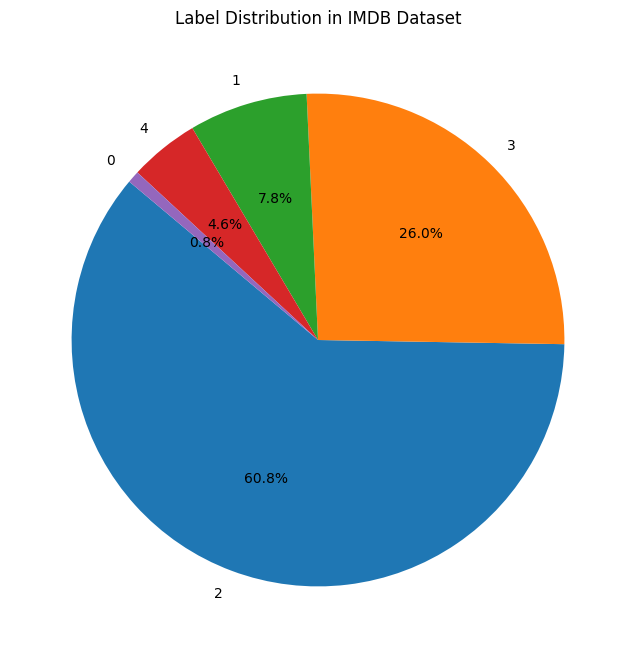

In [223]:
label_counts = pd.Series(y_train_m2).value_counts()

# distriution of the label
plt.figure(figsize=(8, 8))  
plt.pie(label_counts, labels=label_counts.index, autopct='%1.1f%%', startangle=140)
plt.title('Label Distribution in IMDB Dataset')
plt.show()

In [224]:
X_method2["movie_title"]

0       2
1       2
2       2
3       2
4       3
       ..
2999    2
3000    3
3001    2
3002    2
3003    2
Name: movie_title, Length: 3004, dtype: int64

In [225]:
X_method1.columns

Index(['num_critic_for_reviews', 'duration', 'director_facebook_likes',
       'actor_3_facebook_likes', 'actor_1_facebook_likes', 'gross',
       'num_voted_users', 'num_user_for_reviews', 'language', 'country',
       ...
       'content_rating_GP', 'content_rating_M', 'content_rating_NC-17',
       'content_rating_Not Rated', 'content_rating_PG', 'content_rating_PG-13',
       'content_rating_Passed', 'content_rating_R', 'content_rating_Unrated',
       'content_rating_X'],
      dtype='object', length=326)

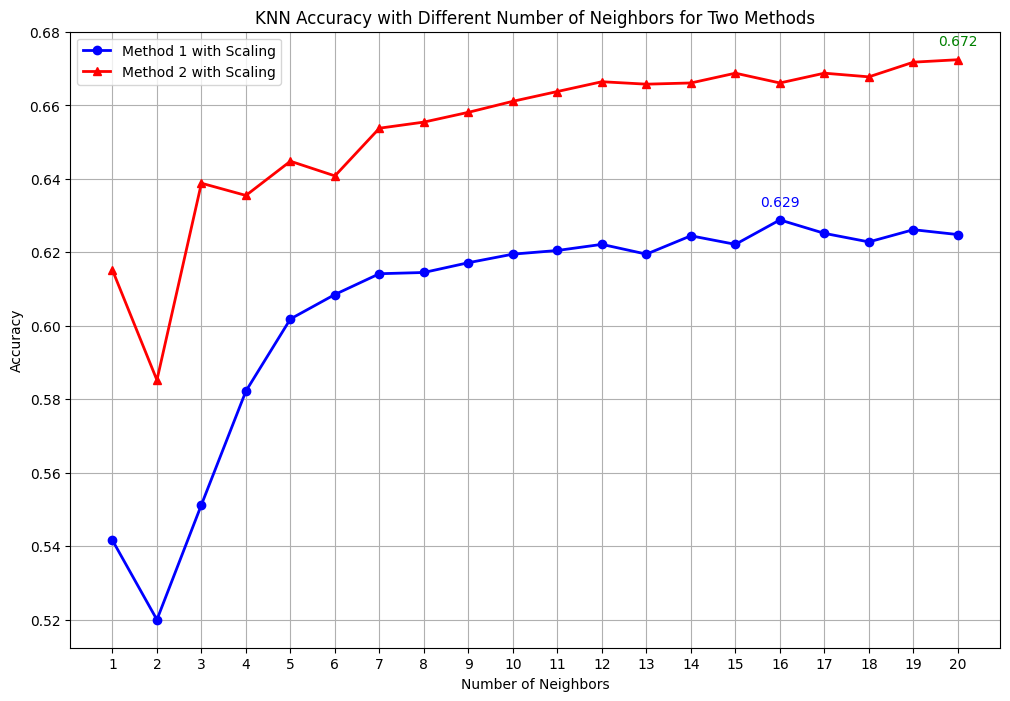

In [226]:

from sklearn.model_selection import StratifiedKFold
from sklearn.model_selection import GridSearchCV

# knn nested cross validation, to get the best k, you can get it from the graph
def nested_cross_validation_accuracies(X, y, num_outer_folds=5, num_inner_folds=5, max_n_neighbors=20):
    outer_cv = StratifiedKFold(n_splits=num_outer_folds, shuffle=True, random_state=42)
    inner_cv = StratifiedKFold(n_splits=num_inner_folds, shuffle=True, random_state=42)
    
    param_grid = {'n_neighbors': list(range(1, max_n_neighbors + 1))}
    all_outer_accuracies = np.zeros((num_outer_folds, max_n_neighbors))

    for i, (train_index, test_index) in enumerate(outer_cv.split(X, y)):
        X_train, X_test = X.iloc[train_index], X.iloc[test_index]
        y_train, y_test = y.iloc[train_index], y.iloc[test_index]

        scaler = StandardScaler()
        X_train_scaled = scaler.fit_transform(X_train)
        X_test_scaled = scaler.transform(X_test)

        knn = KNeighborsClassifier()
        grid_search = GridSearchCV(knn, param_grid, cv=inner_cv, scoring='accuracy')
        grid_search.fit(X_train_scaled, y_train)

        for k in range(1, max_n_neighbors + 1):
            knn = KNeighborsClassifier(n_neighbors=k)
            knn.fit(X_train_scaled, y_train)
            accuracy = accuracy_score(y_test, knn.predict(X_test_scaled))
            all_outer_accuracies[i, k-1] = accuracy
    
    mean_accuracies = np.mean(all_outer_accuracies, axis=0)
    return mean_accuracies
# Calculate accuracies for different n_neighbors
accuracies_method1 = nested_cross_validation_accuracies(X_method1, y_method1)
accuracies_method2 = nested_cross_validation_accuracies(X_method2, y_method2)

# If you want to also consider unscaled versions, you can do it similarly
def nested_cross_validation_accuracies_unscaled(X, y, num_outer_folds=10, num_inner_folds=10, max_n_neighbors=20):
    outer_cv = StratifiedKFold(n_splits=num_outer_folds, shuffle=True, random_state=42)
    inner_cv = StratifiedKFold(n_splits=num_inner_folds, shuffle=True, random_state=42)
    
    param_grid = {'n_neighbors': list(range(1, max_n_neighbors + 1))}
    all_outer_accuracies = np.zeros((num_outer_folds, max_n_neighbors))

    for i, (train_index, test_index) in enumerate(outer_cv.split(X, y)):
        X_train, X_test = X.iloc[train_index], X.iloc[test_index]
        y_train, y_test = y.iloc[train_index], y.iloc[test_index]

        knn = KNeighborsClassifier()
        grid_search = GridSearchCV(knn, param_grid, cv=inner_cv, scoring='accuracy', n_jobs=-1)
        grid_search.fit(X_train, y_train)

        for k in range(1, max_n_neighbors + 1):
            knn = KNeighborsClassifier(n_neighbors=k)
            knn.fit(X_train, y_train)
            accuracy = accuracy_score(y_test, knn.predict(X_test))
            all_outer_accuracies[i, k-1] = accuracy
    
    mean_accuracies = np.mean(all_outer_accuracies, axis=0)
    return mean_accuracies

# Calculate accuracies for different n_neighbors without scaling
accuracies_method1_unscaled = nested_cross_validation_accuracies_unscaled(X_method1, y_method1)
accuracies_method2_unscaled = nested_cross_validation_accuracies_unscaled(X_method2, y_method2)


# Set the range of n_neighbors
neighbors_settings = list(range(1, 21))

# Define colors for each method
colors = ['blue', 'green', 'red', 'purple']

# Create a plot
plt.figure(figsize=(12, 8))

# Plot each method's accuracies
plt.plot(neighbors_settings, accuracies_method1, marker='o', linestyle='-', linewidth=2, markersize=6, color=colors[0], label='Method 1 with Scaling')
plt.plot(neighbors_settings, accuracies_method2, marker='^', linestyle='-', linewidth=2, markersize=6, color=colors[2], label='Method 2 with Scaling')


# Annotate the maximum accuracy points
max_indexes = [
    np.argmax(accuracies_method1),
    np.argmax(accuracies_method2)
]
accuracies_lists = [accuracies_method1,  accuracies_method2]

for i, max_index in enumerate(max_indexes):
    max_x = neighbors_settings[max_index]
    max_y = accuracies_lists[i][max_index]
    plt.annotate(f'{max_y:.3f}', (max_x, max_y), textcoords="offset points", xytext=(0, 10), ha='center', color=colors[i])

# Set x-axis ticks
plt.xticks(neighbors_settings)

# Add labels and title
plt.xlabel('Number of Neighbors')
plt.ylabel('Accuracy')
plt.title('KNN Accuracy with Different Number of Neighbors for Two Methods')

# Add legend
plt.legend()

# Show grid
plt.grid(True)

# Show plot
plt.show()


In [296]:
knn_model = KNeighborsClassifier(n_neighbors=20)
knn_model.fit(X_train_m2, y_train_m2)
knn_pred = knn_model.predict(X_test_m2)



In [237]:
accuracy = accuracy_score(y_test_m2, knn_pred)
print(f"Accuracy: {accuracy}")


Accuracy: 0.6572379367720466


In [239]:
# importance report
from sklearn.metrics import classification_report
report = classification_report(y_test_m2, knn_pred, digits=3)
print("Classification Report for KNN:")
print(report)

Classification Report for KNN:
              precision    recall  f1-score   support

           0      0.000     0.000     0.000         5
           1      0.500     0.021     0.040        48
           2      0.661     0.968     0.786       377
           3      0.617     0.191     0.291       152
           4      0.000     0.000     0.000        19

    accuracy                          0.657       601
   macro avg      0.356     0.236     0.223       601
weighted avg      0.611     0.657     0.570       601



/opt/anaconda3/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/opt/anaconda3/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/opt/anaconda3/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


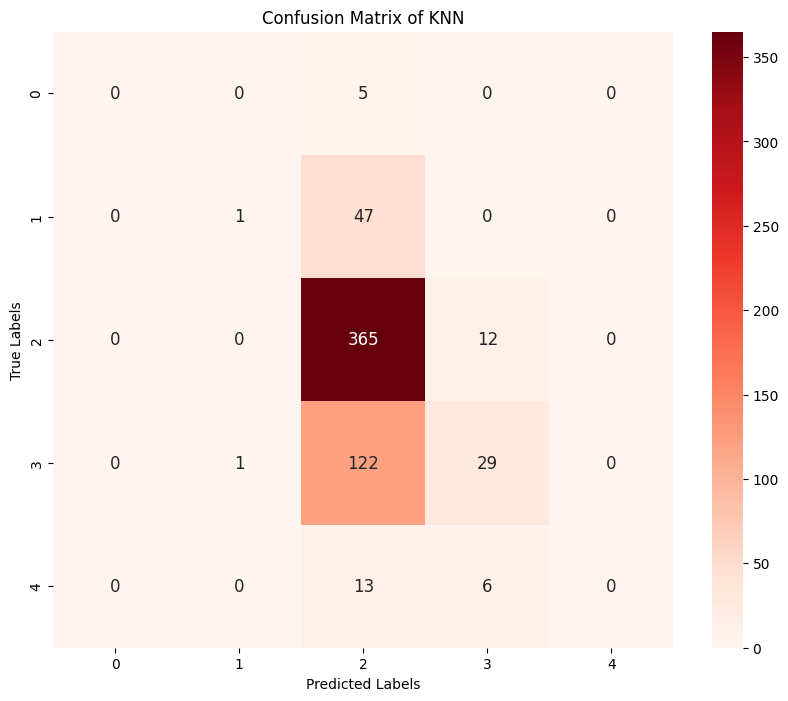

In [240]:
# confusion matric of the knn
from sklearn.metrics import confusion_matrix
cm_knn = confusion_matrix(y_test_m2, knn_pred)

plt.figure(figsize=(10, 8)) 
sns.heatmap(cm_knn, annot=True, fmt='d', cmap='Reds', cbar=True, annot_kws={"size": 12})  
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.title('Confusion Matrix of KNN')
plt.show()


In [241]:
cm_knn

array([[  0,   0,   5,   0,   0],
       [  0,   1,  47,   0,   0],
       [  0,   0, 365,  12,   0],
       [  0,   1, 122,  29,   0],
       [  0,   0,  13,   6,   0]])

## Logistic Regression

In [244]:
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler


In [245]:
# nested cross val of logistic regression to get better several hyperparameters
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

def perform_nested_cv_lr(X, y, num_outer_folds=5, num_inner_folds=5):
    outer_cv = StratifiedKFold(n_splits=num_outer_folds, shuffle=True, random_state=42)
    best_overall_score = -np.inf
    best_overall_params = None
    C_accuracy = {C: [] for C in [0.01, 0.1, 1, 10, 100, 150]}
    for train_index, test_index in outer_cv.split(X, y):
        X_train, X_test = X.iloc[train_index], X.iloc[test_index]
        y_train, y_test = y.iloc[train_index], y.iloc[test_index]

        model = Pipeline([
            ('scaler', StandardScaler()),
            ('logreg', LogisticRegression(random_state=42, max_iter=1000))
        ])

        param_grid = {
            'logreg__C': [0.01, 0.1, 1, 10, 100, 150],
            'logreg__solver': ['liblinear', 'lbfgs']
        }

        grid_search = GridSearchCV(estimator=model,
                                   param_grid=param_grid,
                                   cv=StratifiedKFold(n_splits=num_inner_folds, shuffle=True, random_state=42),
                                   scoring='accuracy')
        grid_search.fit(X_train, y_train)
        for i, params in enumerate(grid_search.cv_results_['params']):
            C = params['logreg__C']
            mean_score = grid_search.cv_results_['mean_test_score'][i]
            C_accuracy[C].append(mean_score)
        # Check if the best score from this fold is the best overall
        if grid_search.best_score_ > best_overall_score:
            best_overall_score = grid_search.best_score_
            best_overall_params = grid_search.best_params_
    average_C_accuracy = {C: np.mean(scores) for C, scores in C_accuracy.items()}
    return best_overall_score, best_overall_params, average_C_accuracy

# Usage example
best_score, best_params, average_C_accuracy = perform_nested_cv_lr(X_train_m2, y_train_m2)
print(f"Best Overall Accuracy: {best_score}")
print(f"Best Parameters: {best_params}")
print("Average Accuracy for each C value:", average_C_accuracy)


Best Overall Accuracy: 0.7232088744588745
Best Parameters: {'logreg__C': 1, 'logreg__solver': 'lbfgs'}
Average Accuracy for each C value: {0.01: 0.6756714015151515, 0.1: 0.6960589826839827, 1: 0.7079201839826841, 10: 0.7087520292207793, 100: 0.7086473214285713, 150: 0.7084391233766234}


In [246]:
from sklearn.metrics import classification_report
lr_model = Pipeline([
    ('scaler', StandardScaler()),
    ('logreg', LogisticRegression(
        random_state=42))
])

# normalise
lr_model.fit(X_train_m2, y_train_m2)
lr_y_pred = lr_model.predict(X_test_m2)

# classition
report = classification_report(y_test_m2, lr_y_pred, digits=3)
print("Classification Report for Logistic Regression:")
print(report)

Classification Report for Logistic Regression:
              precision    recall  f1-score   support

           0      0.000     0.000     0.000         5
           1      0.333     0.042     0.074        48
           2      0.745     0.912     0.820       377
           3      0.708     0.526     0.604       152
           4      0.650     0.684     0.667        19

    accuracy                          0.730       601
   macro avg      0.487     0.433     0.433       601
weighted avg      0.693     0.730     0.694       601



/opt/anaconda3/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:458: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/opt/anaconda3/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/opt/anaconda3/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 i

In [297]:
from sklearn.metrics import classification_report
lr_model = Pipeline([
    ('scaler', StandardScaler()),
    ('logreg', LogisticRegression(
        C=1,  # hyper para from the NCV
        solver='lbfgs',
        max_iter=1000,
        random_state=42))
])

##normalise
lr_model.fit(X_train_m2, y_train_m2)
lr_y_pred = lr_model.predict(X_test_m2)

# classfication
report = classification_report(y_test_m2, lr_y_pred,digits=3)
print("Classification Report for Logistic Regression:")
print(report)

Classification Report for Logistic Regression:
              precision    recall  f1-score   support

           0      0.000     0.000     0.000         5
           1      0.333     0.042     0.074        48
           2      0.745     0.912     0.820       377
           3      0.708     0.526     0.604       152
           4      0.650     0.684     0.667        19

    accuracy                          0.730       601
   macro avg      0.487     0.433     0.433       601
weighted avg      0.693     0.730     0.694       601



/opt/anaconda3/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/opt/anaconda3/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/opt/anaconda3/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


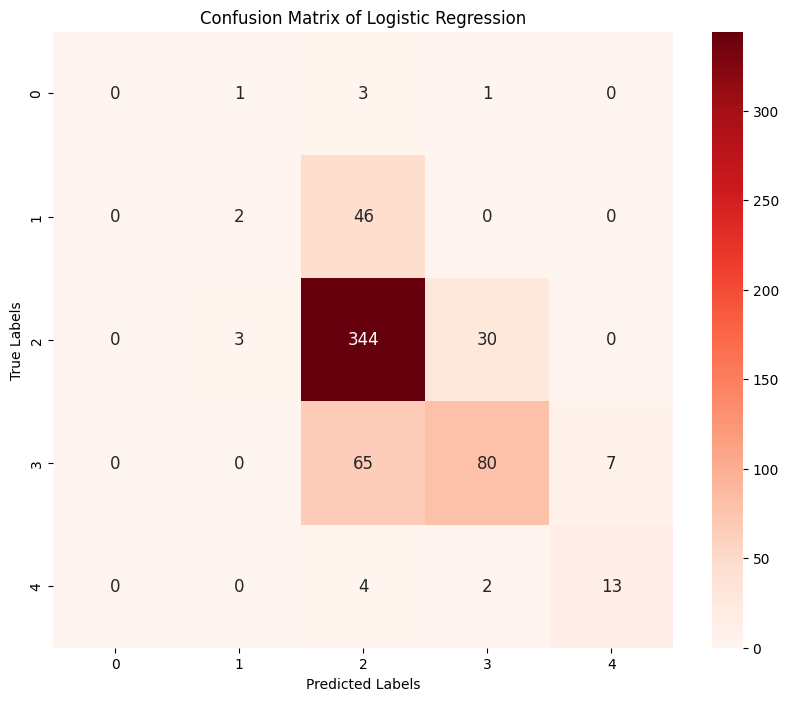

In [248]:
lr_cm = confusion_matrix(y_test_m2, lr_y_pred)
# heatmap
plt.figure(figsize=(10, 8))  #
sns.heatmap(lr_cm, annot=True, fmt='d', cmap='Reds', cbar=True, annot_kws={"size": 12})  # 调整注释字体大小
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.title('Confusion Matrix of Logistic Regression')
plt.show()


In [249]:
lr_cm

array([[  0,   1,   3,   1,   0],
       [  0,   2,  46,   0,   0],
       [  0,   3, 344,  30,   0],
       [  0,   0,  65,  80,   7],
       [  0,   0,   4,   2,  13]])

/opt/anaconda3/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:458: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/opt/anaconda3/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:458: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_ite

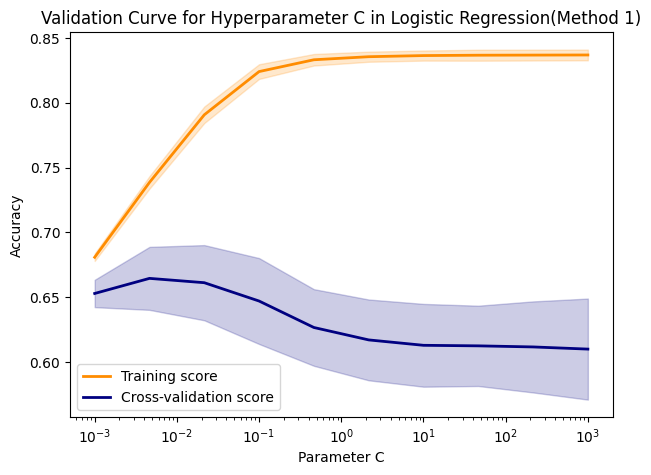

In [250]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import validation_curve
from sklearn.datasets import load_iris


# validation curve for using the preprocessiong method 1
param_range = np.logspace(-3, 3, 10) 

# calculate curve
train_scores, test_scores = validation_curve(
    Pipeline([('scaler', StandardScaler()), ('logreg', LogisticRegression(solver='lbfgs', max_iter=1000, random_state=42))]),
    X_train_m1, y_train_m1,
    param_name="logreg__C", 
    param_range=param_range,
    cv=10,
    scoring="accuracy",
    n_jobs=-1
)

# Calculate mean and standard deviation
train_mean = np.mean(train_scores, axis=1)
train_std = np.std(train_scores, axis=1)
test_mean = np.mean(test_scores, axis=1)
test_std = np.std(test_scores, axis=1)

# draw
plt.figure(figsize=(7, 5))
plt.semilogx(param_range, train_mean, label="Training score", color="darkorange", lw=2)
plt.fill_between(param_range, train_mean - train_std, train_mean + train_std, color="darkorange", alpha=0.2)
plt.semilogx(param_range, test_mean, label="Cross-validation score", color="navy", lw=2)
plt.fill_between(param_range, test_mean - test_std, test_mean + test_std, color="navy", alpha=0.2)

plt.title("Validation Curve for Hyperparameter C in Logistic Regression(Method 1)")
plt.xlabel("Parameter C")
plt.ylabel("Accuracy")
plt.legend(loc="best")
plt.show()


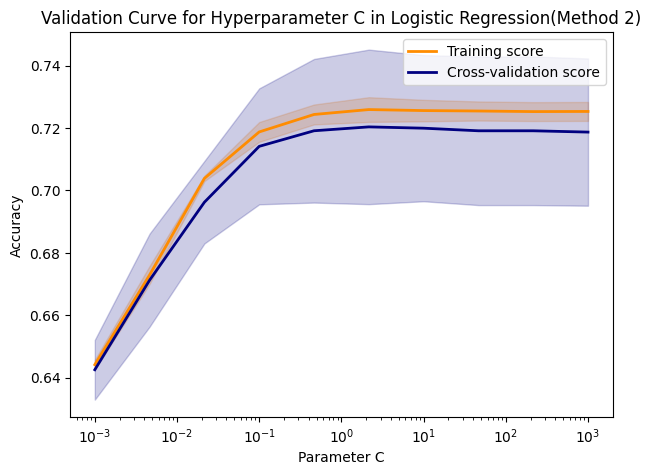

In [251]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import validation_curve
from sklearn.datasets import load_iris

# validation curve for using the preprocessiong method 2
param_range = np.logspace(-3, 3, 10)  # C 0.001 to 1000

# calculate validation
train_scores, test_scores = validation_curve(
    Pipeline([('scaler', StandardScaler()), ('logreg', LogisticRegression(solver='lbfgs', max_iter=1000, random_state=42))]),
    X_train_m2, y_train_m2,
    param_name="logreg__C",  
    param_range=param_range,
    cv=10,
    scoring="accuracy",
    n_jobs=-1
)

# mean
train_mean = np.mean(train_scores, axis=1)
train_std = np.std(train_scores, axis=1)
test_mean = np.mean(test_scores, axis=1)
test_std = np.std(test_scores, axis=1)

# validation curve
plt.figure(figsize=(7, 5))
plt.semilogx(param_range, train_mean, label="Training score", color="darkorange", lw=2)
plt.fill_between(param_range, train_mean - train_std, train_mean + train_std, color="darkorange", alpha=0.2)
plt.semilogx(param_range, test_mean, label="Cross-validation score", color="navy", lw=2)
plt.fill_between(param_range, test_mean - test_std, test_mean + test_std, color="navy", alpha=0.2)

plt.title("Validation Curve for Hyperparameter C in Logistic Regression(Method 2)")
plt.xlabel("Parameter C")
plt.ylabel("Accuracy")
plt.legend(loc="best")
plt.show()


## XGboost

In [252]:
from xgboost import XGBClassifier
from sklearn.model_selection import GridSearchCV

In [253]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GridSearchCV, StratifiedKFold
import xgboost as xgb

# nested cross val of XGB to get better several hyperparameters
def perform_nested_cv_xgb(X, y, num_outer_folds=5, num_inner_folds=5):
    outer_cv = StratifiedKFold(n_splits=num_outer_folds, shuffle=True, random_state=42)
    
    best_overall_score = -np.inf
    best_overall_params = None
    
    for train_index, test_index in outer_cv.split(X, y):
        X_train, X_test = X.iloc[train_index], X.iloc[test_index]
        y_train, y_test = y.iloc[train_index], y.iloc[test_index]


        model = Pipeline([
            ('scaler', StandardScaler()),  
            ('xgb', xgb.XGBClassifier(use_label_encoder=False, eval_metric='mlogloss', random_state=42))
        ])

        param_grid = {
            'xgb__n_estimators': [20, 50, 80,100],
            'xgb__max_depth': [3, 5, 7],
            'xgb__learning_rate': [0.01, 0.1, 0.2]

            
        }

        inner_cv = StratifiedKFold(n_splits=num_inner_folds, shuffle=True, random_state=42)
        grid_search = GridSearchCV(estimator=model, param_grid=param_grid, cv=inner_cv, scoring='accuracy', n_jobs=-1)
        grid_search.fit(X_train, y_train)

        if grid_search.best_score_ > best_overall_score:
            best_overall_score = grid_search.best_score_
            best_overall_params = grid_search.best_params_

    return best_overall_score, best_overall_params

# use function
best_score, best_params = perform_nested_cv_xgb(X_train_m2, y_train_m2)
print(f"Best Overall Accuracy: {best_score}")
print(f"Best Parameters: {best_params}")


Best Overall Accuracy: 0.7284050324675324
Best Parameters: {'xgb__learning_rate': 0.2, 'xgb__max_depth': 5, 'xgb__n_estimators': 50}


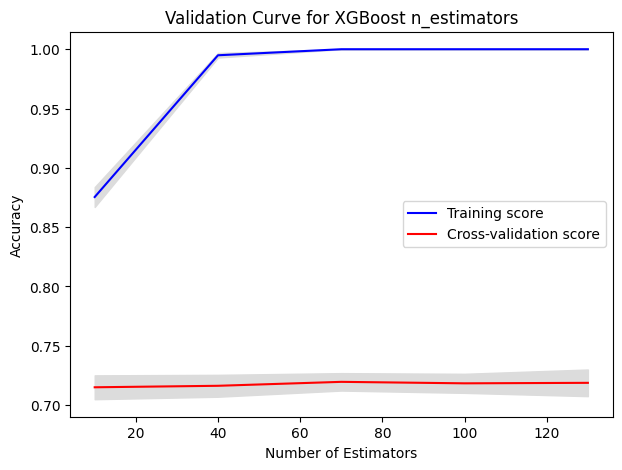

In [254]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import validation_curve
from sklearn.model_selection import StratifiedKFold
import xgboost as xgb
# validation curve for the xgb boost
X, y = X_train_m2, y_train_m2  


model = xgb.XGBClassifier(use_label_encoder=False, eval_metric='mlogloss', random_state=42)


param_range = np.arange(10, 150, 30)


train_scores, test_scores = validation_curve(
    model, X, y, param_name="n_estimators", param_range=param_range,
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42), scoring="accuracy", n_jobs=-1)


train_mean = np.mean(train_scores, axis=1)
train_std = np.std(train_scores, axis=1)
test_mean = np.mean(test_scores, axis=1)
test_std = np.std(test_scores, axis=1)


plt.figure(figsize=(7, 5))
plt.plot(param_range, train_mean, label="Training score", color="blue")
plt.fill_between(param_range, train_mean - train_std, train_mean + train_std, color="gainsboro")
plt.plot(param_range, test_mean, label="Cross-validation score", color="red")
plt.fill_between(param_range, test_mean - test_std, test_mean + test_std, color="gainsboro")
plt.title("Validation Curve for XGBoost n_estimators")
plt.xlabel("Number of Estimators")
plt.ylabel("Accuracy")
plt.legend(loc="best")
plt.show()


In [255]:
import xgboost as xgb
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, accuracy_score


# model with default hyperpara
xgb_model = Pipeline([
    ('scaler', StandardScaler()),  
    ('xgb', xgb.XGBClassifier())
])
# normalise
xgb_model.fit(X_train_m2, y_train_m2)
xgb_y_pred = xgb_model.predict(X_test_m2)
train_accuracy = accuracy_score(y_train_m2, xgb_model.predict(X_train_m2))
test_accuracy = accuracy_score(y_test_m2, xgb_y_pred)
# print
print("Accuracy on training data: {:.2f}%".format(train_accuracy * 100))
print("Accuracy on test data: {:.2f}%".format(test_accuracy * 100))
# classification plot
report = classification_report(y_test_m2, xgb_y_pred,digits=3)
print("Classification Report for XGboost:")
print(report)

Accuracy on training data: 100.00%
Accuracy on test data: 73.38%
Classification Report for XGboost:
              precision    recall  f1-score   support

           0      0.000     0.000     0.000         5
           1      0.533     0.167     0.254        48
           2      0.769     0.891     0.826       377
           3      0.667     0.566     0.612       152
           4      0.611     0.579     0.595        19

    accuracy                          0.734       601
   macro avg      0.516     0.441     0.457       601
weighted avg      0.713     0.734     0.712       601



In [256]:
from sklearn.metrics import f1_score
f1_xgb = f1_score(y_test_m2, xgb_y_pred, average='weighted')
f1_xgb

0.7117476449728154

In [257]:
xgb_cm = confusion_matrix(y_test_m2, xgb_y_pred)
xgb_cm

array([[  0,   1,   3,   1,   0],
       [  2,   8,  38,   0,   0],
       [  0,   6, 336,  35,   0],
       [  0,   0,  59,  86,   7],
       [  0,   0,   1,   7,  11]])

In [298]:
import xgboost as xgb
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, accuracy_score


# Create a model with optimal parameters
xgb_model = Pipeline([
    ('scaler', StandardScaler()), 
    ('xgb', xgb.XGBClassifier(
        n_estimators=50,
        max_depth=5,
        learning_rate=0.2,
        use_label_encoder=False,
        eval_metric='mlogloss',
        random_state=42))
])
##normalise
xgb_model.fit(X_train_m2, y_train_m2)
xgb_y_pred = xgb_model.predict(X_test_m2)
train_accuracy = accuracy_score(y_train_m2, xgb_model.predict(X_train_m2))
test_accuracy = accuracy_score(y_test_m2, xgb_y_pred)
# print acc
print("Accuracy on training data: {:.2f}%".format(train_accuracy * 100))
print("Accuracy on test data: {:.2f}%".format(test_accuracy * 100))
# classification report
report = classification_report(y_test_m2, xgb_y_pred,digits=3)
print("Classification Report for XGboost:")
print(report)

Accuracy on training data: 92.93%
Accuracy on test data: 74.21%
Classification Report for XGboost:
              precision    recall  f1-score   support

           0      0.000     0.000     0.000         5
           1      0.714     0.104     0.182        48
           2      0.767     0.907     0.831       377
           3      0.679     0.586     0.629       152
           4      0.667     0.526     0.588        19

    accuracy                          0.742       601
   macro avg      0.565     0.425     0.446       601
weighted avg      0.731     0.742     0.714       601



In [259]:
from sklearn.metrics import f1_score
f1_xgb = f1_score(y_test_m2, xgb_y_pred, average='weighted')
f1_xgb

0.713535501788864

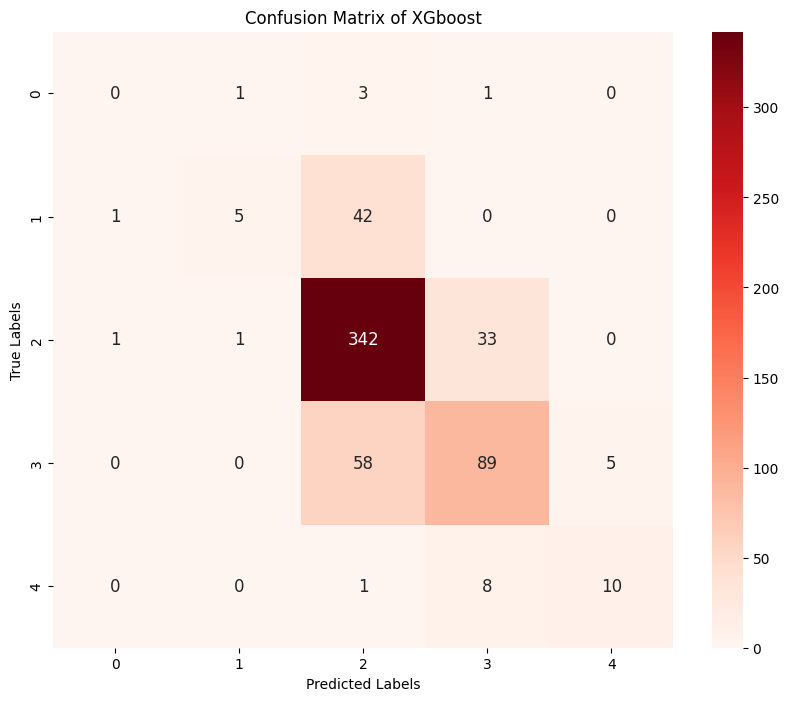

In [260]:
xgb_cm = confusion_matrix(y_test_m2, xgb_y_pred)

plt.figure(figsize=(10, 8))
sns.heatmap(xgb_cm, annot=True, fmt='d', cmap='Reds', cbar=True, annot_kws={"size": 12}) 
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.title('Confusion Matrix of XGboost')
plt.show()


In [261]:
xgb_cm

array([[  0,   1,   3,   1,   0],
       [  1,   5,  42,   0,   0],
       [  1,   1, 342,  33,   0],
       [  0,   0,  58,  89,   5],
       [  0,   0,   1,   8,  10]])

## Random Forest

In [262]:
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import StratifiedKFold, GridSearchCV
import numpy as np
# nested cross val of RF to get better several hyperparameters
def perform_nested_cv(X, y, num_outer_folds=5, num_inner_folds=5, param_grid=None):
    if param_grid is None:
        param_grid = {
            'classifier__n_estimators': [100, 200, 250],
            'classifier__max_depth': [None, 30, 40],
            'classifier__min_samples_split': [2, 5, 10]
        }

    outer_cv = StratifiedKFold(n_splits=num_outer_folds, shuffle=True, random_state=42)
    
    best_params_each_fold = []
    best_score_each_fold = []
    train_scores = []
    valid_scores = []
    all_cv_results = []  # List to store all cv_results_ objects

    model = Pipeline([
        ('scaler', StandardScaler()), 
        ('classifier', RandomForestClassifier(random_state=42))
    ])

    for train_index, test_index in outer_cv.split(X, y):
        X_train, X_test = X.iloc[train_index], X.iloc[test_index]
        y_train, y_test = y.iloc[train_index], y.iloc[test_index]

        inner_cv = StratifiedKFold(n_splits=num_inner_folds, shuffle=True, random_state=42)
        grid_search = GridSearchCV(estimator=model, param_grid=param_grid, cv=inner_cv, scoring='accuracy', n_jobs=-1)
        grid_search.fit(X_train, y_train)
        
        train_scores.append(grid_search.best_estimator_.score(X_train, y_train))
        valid_scores.append(grid_search.best_score_)
        
        best_params = grid_search.best_params_
        best_model = grid_search.best_estimator_
        best_score = best_model.score(X_test, y_test)
        best_params_each_fold.append(best_params)
        best_score_each_fold.append(best_score)
        all_cv_results.append(grid_search.cv_results_)  # Store results from grid search

    best_index = np.argmax(best_score_each_fold)
    best_params_overall = best_params_each_fold[best_index]
    best_score_overall = best_score_each_fold[best_index]

    print(f"Best parameters across folds: {best_params_overall}")
    print(f"Best accuracy score across folds: {best_score_overall}")

    return best_params_overall, best_score_overall, train_scores, valid_scores, all_cv_results

# Usage example, assuming X and y are defined:
# best_params, best_score, train_scores, valid_scores, all_cv_results = perform_nested_cv(X, y)


In [263]:
# method 2 without standarazation
best_params, best_accuracy, train_scores, valid_scores, all_cv_results = perform_nested_cv(X_train_m2, y_train_m2)

Best parameters across folds: {'classifier__max_depth': None, 'classifier__min_samples_split': 2, 'classifier__n_estimators': 250}
Best accuracy score across folds: 0.7354166666666667


/var/folders/c8/ss65_vp15r35d2dnjcq75cgc0000gn/T/ipykernel_43063/543376841.py:21: FutureWarning: The provided callable <function mean at 0x10b27af20> is currently using DataFrameGroupBy.mean. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "mean" instead.
  pivot_table = df.pivot_table(


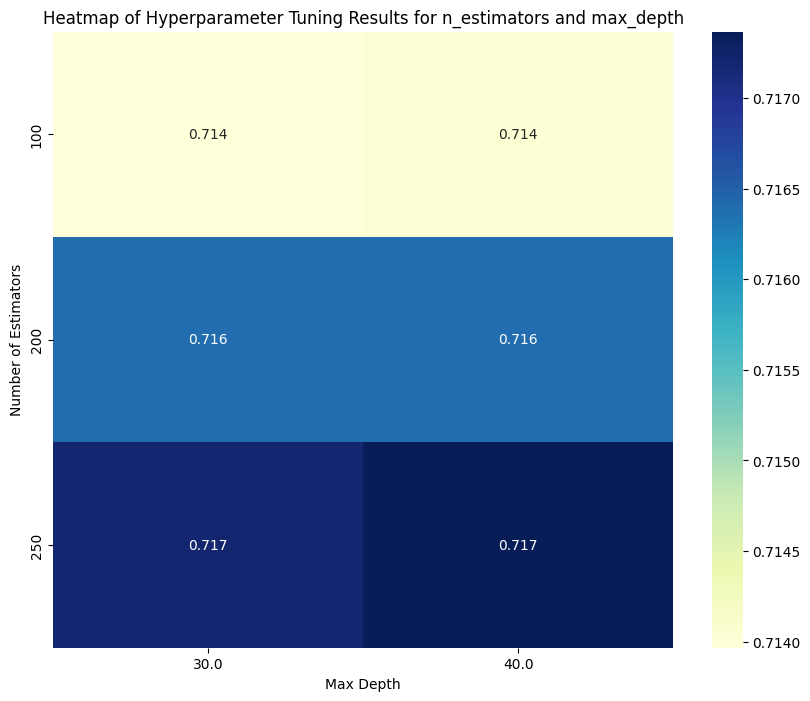

In [264]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
# plot heatmap of different hyperparameter n estimator and max depth for RF
def plot_hyperparameter_heatmap(all_cv_results):

    param_scores = []

    for results in all_cv_results:
        for score, params in zip(results['mean_test_score'], results['params']):
            param_scores.append({
                'n_estimators': params['classifier__n_estimators'],
                'max_depth': params['classifier__max_depth'],
                'score': score
            })


    df = pd.DataFrame(param_scores)

    pivot_table = df.pivot_table(
        values='score',
        index='n_estimators',
        columns='max_depth',
        aggfunc=np.mean
    )

    plt.figure(figsize=(10, 8))
    sns.heatmap(pivot_table, annot=True, cmap="YlGnBu", fmt=".3f")
    plt.title("Heatmap of Hyperparameter Tuning Results for n_estimators and max_depth")
    plt.xlabel("Max Depth")
    plt.ylabel("Number of Estimators")
    plt.show()

# plot_hyperparameter_heatmap(all_cv_results)
plot_hyperparameter_heatmap(all_cv_results)

In [292]:
rf_model = Pipeline([
    ('scaler', StandardScaler()), 
    ('classifier', RandomForestClassifier())
])
##normalise
rf_model.fit(X_train_m2, y_train_m2)
rf_y_pred = rf_model.predict(X_test_m2)
# calculate acc
train_accuracy = accuracy_score(y_train_m2, rf_model.predict(X_train_m2))
test_accuracy = accuracy_score(y_test_m2, rf_y_pred)


print("Accuracy on training data: {:.2f}%".format(train_accuracy * 100))
print("Accuracy on test data: {:.2f}%".format(test_accuracy * 100))


# classification report
report = classification_report(y_test_m2, rf_y_pred, digits=3)
print("Classification Report for Random Forest Model:")
print(report)

Accuracy on training data: 100.00%
Accuracy on test data: 72.38%
Classification Report for Random Forest Model:
              precision    recall  f1-score   support

           0      0.000     0.000     0.000         5
           1      1.000     0.062     0.118        48
           2      0.744     0.910     0.819       377
           3      0.651     0.539     0.590       152
           4      0.636     0.368     0.467        19

    accuracy                          0.724       601
   macro avg      0.606     0.376     0.399       601
weighted avg      0.731     0.724     0.687       601



/opt/anaconda3/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/opt/anaconda3/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/opt/anaconda3/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


In [293]:
rf_cm = confusion_matrix(y_test_m2, rf_y_pred)
rf_cm

array([[  0,   0,   4,   1,   0],
       [  0,   3,  45,   0,   0],
       [  0,   0, 343,  34,   0],
       [  0,   0,  66,  82,   4],
       [  0,   0,   3,   9,   7]])

In [294]:
from sklearn.metrics import f1_score
f1_rf = f1_score(y_test_m2, rf_y_pred, average='weighted')
f1_rf

0.686856786461262

In [299]:
# moel with better parameter
rf_model = Pipeline([
    ('scaler', StandardScaler()), 
    ('classifier', RandomForestClassifier(
        n_estimators=250,
        max_depth=None,
        min_samples_split=2,
        random_state=42))
])
# normalise
rf_model.fit(X_train_m2, y_train_m2)
rf_y_pred = rf_model.predict(X_test_m2)

train_accuracy = accuracy_score(y_train_m2, rf_model.predict(X_train_m2))
test_accuracy = accuracy_score(y_test_m2, rf_y_pred)


print("Accuracy on training data: {:.2f}%".format(train_accuracy * 100))
print("Accuracy on test data: {:.2f}%".format(test_accuracy * 100))



report = classification_report(y_test_m2, rf_y_pred, digits=3)
print("Classification Report for Random Forest Model:")
print(report)

Accuracy on training data: 100.00%
Accuracy on test data: 73.21%
Classification Report for Random Forest Model:
              precision    recall  f1-score   support

           0      0.000     0.000     0.000         5
           1      1.000     0.021     0.041        48
           2      0.751     0.920     0.827       377
           3      0.669     0.559     0.609       152
           4      0.636     0.368     0.467        19

    accuracy                          0.732       601
   macro avg      0.611     0.374     0.389       601
weighted avg      0.740     0.732     0.691       601



/opt/anaconda3/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/opt/anaconda3/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/opt/anaconda3/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


In [289]:
from sklearn.metrics import f1_score
f1_rf = f1_score(y_test_m2, rf_y_pred, average='weighted')
f1_rf

0.6909939957248142

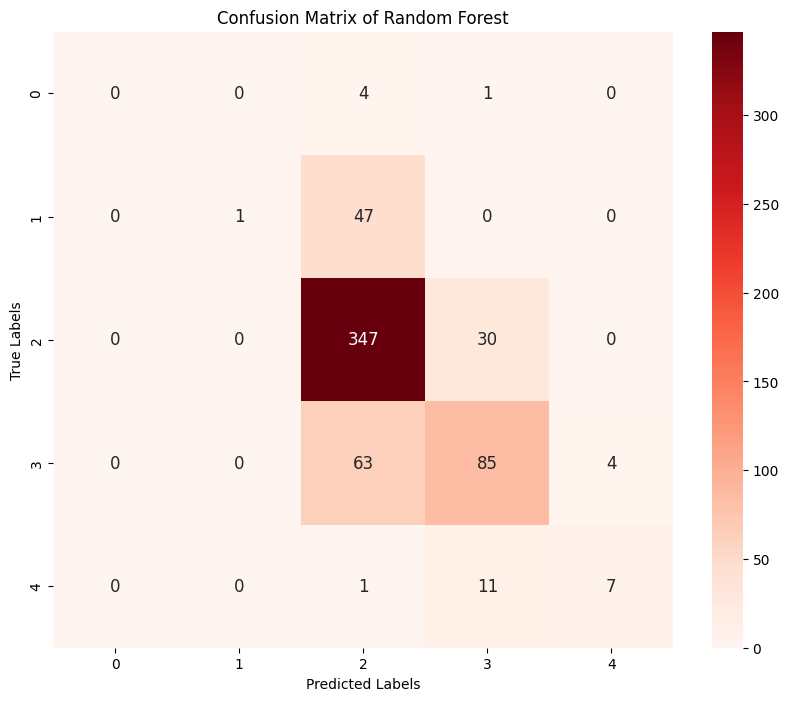

In [278]:
rf_cm = confusion_matrix(y_test_m2, rf_y_pred)

plt.figure(figsize=(10, 8))  
sns.heatmap(rf_cm, annot=True, fmt='d', cmap='Reds', cbar=True, annot_kws={"size": 12})  # 调整注释字体大小
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.title('Confusion Matrix of Random Forest')
plt.show()


In [279]:
rf_cm

array([[  0,   0,   4,   1,   0],
       [  0,   1,  47,   0,   0],
       [  0,   0, 347,  30,   0],
       [  0,   0,  63,  85,   4],
       [  0,   0,   1,  11,   7]])

## Stacking

In [300]:
from sklearn.ensemble import StackingClassifier

# base model we used
stacking_model = StackingClassifier(
    estimators=[
        ('rf', rf_model),
        ('xgb', xgb_model),
        ('lr', lr_model)
    ],
    final_estimator=LogisticRegression(random_state=42),  # beta model
    cv=5  # inner cv
)
from sklearn.model_selection import StratifiedKFold, cross_val_score

# outer cv
outer_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# evaluestion
scores = cross_val_score(stacking_model, X_train_m2, y_train_m2, cv=outer_cv, scoring='accuracy')
print(f"Mean cross-validation score of the stacking model: {scores.mean()}")



# stacking
stacking_model.fit(X_train_m2, y_train_m2)

accuracy = stacking_model.score(X_test_m2, y_test_m2)
print(f"Accuracy on the test set: {accuracy}")


/opt/anaconda3/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:458: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Mean cross-validation score of the stacking model: 0.7340826403326404
Accuracy on the test set: 0.7437603993344426


In [283]:
y_pred_stack = stacking_model.predict(X_test_m2)

# classification report
report = classification_report(y_test_m2, y_pred_stack, digits=3)
print("Classification Report for Stacking:")
print(report)

Classification Report for Stacking:
              precision    recall  f1-score   support

           0      0.000     0.000     0.000         5
           1      0.545     0.125     0.203        48
           2      0.767     0.902     0.829       377
           3      0.693     0.579     0.631       152
           4      0.650     0.684     0.667        19

    accuracy                          0.744       601
   macro avg      0.531     0.458     0.466       601
weighted avg      0.721     0.744     0.717       601



/opt/anaconda3/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/opt/anaconda3/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/opt/anaconda3/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


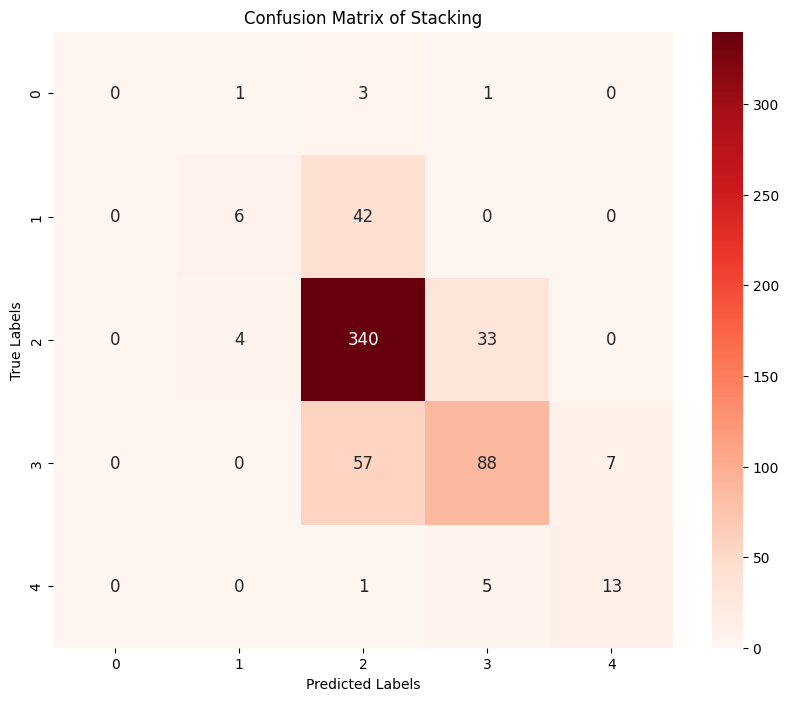

In [301]:
st_cm = confusion_matrix(y_test_m2, y_pred_stack)

plt.figure(figsize=(10, 8)) 
sns.heatmap(st_cm, annot=True, fmt='d', cmap='Reds', cbar=True, annot_kws={"size": 12})  
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.title('Confusion Matrix of Stacking')
plt.show()


In [285]:
st_cm

array([[  0,   1,   3,   1,   0],
       [  0,   6,  42,   0,   0],
       [  0,   4, 340,  33,   0],
       [  0,   0,  57,  88,   7],
       [  0,   0,   1,   5,  13]])

## Final Model ---- you can generate the test label from here

before running the code for this part, you can run the previous 

### Preprocess test data

In [318]:
knn_model = KNeighborsClassifier(n_neighbors=20)

lr_model = Pipeline([
    ('scaler', StandardScaler()),
    ('logreg', LogisticRegression(
        C=1,  # hyper para from the NCV
        solver='lbfgs',
        max_iter=1000,
        random_state=42))
])

xgb_model = Pipeline([
    ('scaler', StandardScaler()), 
    ('xgb', xgb.XGBClassifier(
        n_estimators=50,
        max_depth=5,
        learning_rate=0.2,
        use_label_encoder=False,
        eval_metric='mlogloss',
        random_state=42))
])

rf_model = Pipeline([
    ('scaler', StandardScaler()), 
    ('classifier', RandomForestClassifier(
        n_estimators=250,
        max_depth=None,
        min_samples_split=2,
        random_state=42))
])


In [319]:
stacking_model = StackingClassifier(
    estimators=[
        ('rf', rf_model),
        ('xgb', xgb_model),
        ('lr', lr_model)
    ],
    final_estimator=LogisticRegression(random_state=42),  # beta model
    cv=5  # inner cv
)

In [320]:
# load the test data
test_file_path = 'project_data/test_dataset.csv'
test_genre_path = 'project_data/features_doc2vec/test_doc2vec_features_genre.npy'
test_plot_path = 'project_data/features_doc2vec/test_doc2vec_features_plot_keywords.npy'
test_title_path = 'project_data/features_fasttext/test_fasttext_title_embeddings.npy'

# method 2 to preprocessing the data
test_df_ensem = preprocess_ensemble(test_file_path, test_genre_path, test_plot_path, test_title_path, is_train= False)

In [321]:
test_df_ensem

,id,director_name,num_critic_for_reviews,duration,director_facebook_likes,actor_3_facebook_likes,actor_2_name,actor_1_facebook_likes,gross,genres,...,language,country,content_rating,title_year,actor_2_facebook_likes,movie_facebook_likes,title_embedding,average_degree_centrality,encode_language,encode_country
0,1,Angelo Pizzo,27,118,14,400,Finn Wittrock,2000,2246000,3,...,2,2,2,2015,769,0,[-1.8731274e-03 7.4580857e-05 -1.0176800e-03 ...,0.000375,1,1
1,2,Oliver Stone,339,141,0,404,Shea Whigham,749,47307550,2,...,2,2,2,2012,463,28000,[-9.12924181e-04 -1.82617712e-03 -7.91343977e-...,0.002176,1,1
2,3,Peter Stebbings,78,95,89,388,Tony Nappo,963,37606,2,...,2,2,2,2009,654,0,[-2.2053068e-04 -8.8869774e-04 1.3940284e-04 ...,0.000900,1,0
3,4,Sam Mendes,226,117,0,818,Jennifer Jason Leigh,15000,104054514,2,...,2,2,2,2002,1000,0,[-7.79978640e-04 1.89176446e-03 1.27516838e-...,0.003452,1,1
4,5,Maggie Carey,97,104,38,690,Alia Shawkat,801,3447339,2,...,2,2,2,2013,727,0,[-2.7749534e-03 4.2528817e-03 3.0464510e-04 ...,0.000450,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
747,748,Wes Anderson,179,93,0,766,Connie Nielsen,13000,17096053,2,...,2,2,2,1998,933,5000,[ 1.09036407e-03 9.97057534e-04 1.00447156e-...,0.002777,1,1
748,749,Timur Bekmambetov,393,105,335,911,Dominic Cooper,3000,37516013,2,...,2,2,2,2012,3000,98000,[-1.08148111e-03 4.01404919e-04 -1.11769295e-...,0.001801,1,1
749,750,James Ivory,55,117,133,249,Rupert Graves,687,20966644,3,...,2,2,2,1985,443,0,[-3.1453588e-03 1.6468379e-03 1.3859679e-04 ...,0.001126,1,0
750,751,Steve Trenbirth,85,72,0,384,Phil Collins,3000,47887943,2,...,2,2,2,2003,455,227,[-4.9067605e-03 2.5930568e-03 -9.7333343e-04 ...,0.000825,1,1


In [322]:
# log transformation for data
log_ensem_test_df = test_df_ensem
columns_to_log = [
    'movie_facebook_likes', 'director_facebook_likes', 'actor_1_facebook_likes',
    'cast_total_facebook_likes', 'actor_2_facebook_likes', 'actor_3_facebook_likes', 
    'facenumber_in_poster'
]


for column in columns_to_log:
    log_ensem_test_df[column] = np.log1p(log_ensem_test_df[column]) 

In [323]:
columns_to_log = [
    'num_voted_users', 'gross',
    'num_critic_for_reviews', 'num_user_for_reviews', 'average_degree_centrality'
]


for column in columns_to_log:
    log_ensem_test_df[column] = np.log(log_ensem_test_df[column]) # 数值中不有0，用log


log_ensem_test_df 

,id,director_name,num_critic_for_reviews,duration,director_facebook_likes,actor_3_facebook_likes,actor_2_name,actor_1_facebook_likes,gross,genres,...,language,country,content_rating,title_year,actor_2_facebook_likes,movie_facebook_likes,title_embedding,average_degree_centrality,encode_language,encode_country
0,1,Angelo Pizzo,3.295837,118,2.708050,5.993961,Finn Wittrock,7.601402,14.624661,3,...,2,2,2,2015,6.646391,0.000000,[-1.8731274e-03 7.4580857e-05 -1.0176800e-03 ...,-7.888035,1,1
1,2,Oliver Stone,5.826000,141,0.000000,6.003887,Shea Whigham,6.620073,17.672180,2,...,2,2,2,2012,6.139885,10.239996,[-9.12924181e-04 -1.82617712e-03 -7.91343977e-...,-6.130176,1,1
2,3,Peter Stebbings,4.356709,95,4.499810,5.963579,Tony Nappo,6.871091,10.534919,2,...,2,2,2,2009,6.484635,0.000000,[-2.2053068e-04 -8.8869774e-04 1.3940284e-04 ...,-7.012566,1,0
3,4,Sam Mendes,5.420535,117,0.000000,6.708084,Jennifer Jason Leigh,9.615872,18.460425,2,...,2,2,2,2002,6.908755,0.000000,[-7.79978640e-04 1.89176446e-03 1.27516838e-...,-5.668831,1,1
4,5,Maggie Carey,4.574711,104,3.663562,6.538140,Alia Shawkat,6.687109,15.053113,2,...,2,2,2,2013,6.590301,0.000000,[-2.7749534e-03 4.2528817e-03 3.0464510e-04 ...,-7.705712,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
747,748,Wes Anderson,5.187386,93,0.000000,6.642487,Connie Nielsen,9.472782,16.654358,2,...,2,2,2,1998,6.839476,8.517393,[ 1.09036407e-03 9.97057534e-04 1.00447156e-...,-5.886554,1,1
748,749,Timur Bekmambetov,5.973810,105,5.817111,6.815640,Dominic Cooper,8.006701,17.440278,2,...,2,2,2,2012,8.006701,11.492733,[-1.08148111e-03 4.01404919e-04 -1.11769295e-...,-6.319418,1,1
749,750,James Ivory,4.007333,117,4.897840,5.521461,Rupert Graves,6.533789,16.858443,3,...,2,2,2,1985,6.095825,0.000000,[-3.1453588e-03 1.6468379e-03 1.3859679e-04 ...,-6.789422,1,0
750,751,Steve Trenbirth,4.442651,72,0.000000,5.953243,Phil Collins,8.006701,17.684374,2,...,2,2,2,2003,6.122493,5.429346,[-4.9067605e-03 2.5930568e-03 -9.7333343e-04 ...,-7.099577,1,1


In [324]:
# drop the feature
final_drop = ['id',
 'facenumber_in_poster',
 'director_name',
 'actor_2_name',
 'actor_1_name',
 'actor_3_name',
 'title_embedding',
 'encode_language',
 'encode_country',
 'content_rating']

log_ensem_test_clean = log_ensem_test_df.drop(columns=final_drop)

In [325]:
# retrain use whole traning data
knn_model.fit(X_method2, y_method2)

KNeighborsClassifier(n_neighbors=20)

In [326]:
# get prediction of knn
knn_predictions = knn_model.predict(log_ensem_test_clean)
knn_results = pd.DataFrame(knn_predictions, columns=['imdb_score_binned'])
knn_results.index = knn_results.index + 1
knn_results.to_csv('test_label/predictions_knn.csv', index=True, index_label='id')


In [327]:
lr_model.fit(X_method2, y_method2)

Pipeline(steps=[('scaler', StandardScaler()),
                ('logreg',
                 LogisticRegression(C=1, max_iter=1000, random_state=42))])

In [328]:
# get prediction of lr
lr_predictions = lr_model.predict(log_ensem_test_clean)
lr_results = pd.DataFrame(lr_predictions, columns=['imdb_score_binned'])
lr_results.index = lr_results.index + 1
lr_results.to_csv('test_label/predictions_lr.csv', index=True, index_label='id')

In [329]:
xgb_model.fit(X_method2, y_method2)


Pipeline(steps=[('scaler', StandardScaler()),
                ('xgb',
                 XGBClassifier(base_score=None, booster=None, callbacks=None,
                               colsample_bylevel=None, colsample_bynode=None,
                               colsample_bytree=None, device=None,
                               early_stopping_rounds=None,
                               enable_categorical=False, eval_metric='mlogloss',
                               feature_types=None, gamma=None, grow_policy=None,
                               importance_type=None,
                               interaction_constraints=None, learning_rate=0.2,
                               max_bin=None, max_cat_threshold=None,
                               max_cat_to_onehot=None, max_delta_step=None,
                               max_depth=5, max_leaves=None,
                               min_child_weight=None, missing=nan,
                               monotone_constraints=None, multi_strategy=None,
                               n_estimators=50, n_jobs=None,
                               num_parallel_tree=None,
                               objective='multi:softprob', ...))])

In [330]:
# get prediction of xgb
xgb_predictions = xgb_model.predict(log_ensem_test_clean)
xgb_results = pd.DataFrame(xgb_predictions, columns=['imdb_score_binned'])
xgb_results.index = xgb_results.index + 1
xgb_results.to_csv('test_label/predictions_xgb.csv', index=True, index_label='id')

In [331]:
rf_model.fit(X_method2, y_method2)

Pipeline(steps=[('scaler', StandardScaler()),
                ('classifier',
                 RandomForestClassifier(n_estimators=250, random_state=42))])

In [332]:
# get prediction of rf
rf_predictions = rf_model.predict(log_ensem_test_clean)
rf_results = pd.DataFrame(rf_predictions, columns=['imdb_score_binned'])
rf_results.index = rf_results.index + 1
rf_results.to_csv('test_label/predictions_rf.csv', index=True, index_label='id')

In [333]:
stacking_model.fit(X_method2, y_method2)

StackingClassifier(cv=5,
                   estimators=[('rf',
                                Pipeline(steps=[('scaler', StandardScaler()),
                                                ('classifier',
                                                 RandomForestClassifier(n_estimators=250,
                                                                        random_state=42))])),
                               ('xgb',
                                Pipeline(steps=[('scaler', StandardScaler()),
                                                ('xgb',
                                                 XGBClassifier(base_score=None,
                                                               booster=None,
                                                               callbacks=None,
                                                               colsample_bylevel=None,
                                                               colsample_bynode=None,
                                                               colsample_bytree=None,
                                                               device...
                                                               max_leaves=None,
                                                               min_child_weight=None,
                                                               missing=nan,
                                                               monotone_constraints=None,
                                                               multi_strategy=None,
                                                               n_estimators=50,
                                                               n_jobs=None,
                                                               num_parallel_tree=None,
                                                               objective='multi:softprob', ...))])),
                               ('lr',
                                Pipeline(steps=[('scaler', StandardScaler()),
                                                ('logreg',
                                                 LogisticRegression(C=1,
                                                                    max_iter=1000,
                                                                    random_state=42))]))],
                   final_estimator=LogisticRegression(random_state=42))

In [334]:
# this is our final model!!!!
# with best prediction
# get prediction of stacking
st_predictions = stacking_model.predict(log_ensem_test_clean)
st_results = pd.DataFrame(st_predictions, columns=['imdb_score_binned'])
st_results.index = st_results.index + 1
st_results.to_csv('test_label/predictions_st.csv', index=True, index_label='id')